# AC 209b Milestone 3: EDA, Baseline Modeling, and Pipeline Development

**Canvas Project Number:** 66  
**Group Members:** Harry Hu, Tom Shan, Wendy Wang, Kemeng Zhang

## Table of Contents

- [1. Problem Statement Refinement and Introduction](#1.-Problem-Statement-Refinement-and-Introduction)
  - [1.1 Project Introduction](#1.1-Project-Introduction)
  - [1.2 Summary of Milestone 2 Findings](#1.2-Summary-of-Milestone-2-Findings)
  - [1.3 Refined Research Question](#1.3-Refined-Research-Question)
  - [1.4 Project Scope and Structural Constraints](#1.4-Project-Scope-and-Structural-Constraints)
  - [1.5 Working Assumptions Carried Forward](#1.5-Working-Assumptions-Carried-Forward)
  - [1.6 New Insights from Extended EDA](#1.6-New-Insights-from-Extended-EDA)
- [2. Comprehensive EDA Review](#2.-Comprehensive-EDA-Review)
  - [2.1 Data Description](#2.1-Data-Description)
  - [2.2 Extended EDA for Subsampling, Feature, and Model Design](#2.2-Extended-EDA-for-Subsampling,-Feature,-and-Model-Design)
    - [2.2.1 Post quality at the short-length tail](#2.2.1-Post-quality-at-the-short-length-tail)
    - [2.2.2 Author-level feature stability vs post count](#2.2.2-Author-level-feature-stability-vs-post-count)
    - [2.2.3 Author concentration and dominance cap](#2.2.3-Author-concentration-and-dominance-cap)
    - [2.2.4 Source-target transferability for emotion features](#2.2.4-Source-target-transferability-for-emotion-features)
  - [2.3 Data Preparation and Subsampling](#2.3-Data-Preparation-and-Subsampling)
  - [2.4 Feature Engineering](#2.4-Feature-Engineering)
  - [2.5 Modeling Implications from EDA](#2.5-Modeling-Implications-from-EDA)
  - [2.6 Summary of EDA-Driven Decisions](#2.6-Summary-of-EDA-Driven-Decisions)
- [3. Baseline Model Selection and Justification](#3.-Baseline-Model-Selection-and-Justification)
  - [3.1 Goals, Inputs, Outputs, and Architecture](#3.1-Goals,-Inputs,-Outputs,-and-Architecture)
  - [3.2 Author-Level Train / Validation / Test Split](#3.2-Author-Level-Train-/-Validation-/-Test-Split)
  - [3.3 Tokenization and Vocabulary](#3.3-Tokenization-and-Vocabulary)
  - [3.4 Model Definitions](#3.4-Model-Definitions)
  - [3.5 Training Utilities](#3.5-Training-Utilities)
  - [3.6 Baseline 1 - Text-Only RNN](#3.6-Baseline-1---Text-Only-RNN)
  - [3.7 Baseline 2 - Text + Emotion RNN](#3.7-Baseline-2---Text-+-Emotion-RNN)
- [4. Results Interpretation and Analysis](#4.-Results-Interpretation-and-Analysis)
  - [4.1 Comparison Table - Baseline 1 vs. Baseline 2](#4.1-Comparison-Table---Baseline-1-vs.-Baseline-2)
  - [4.2 Confusion Matrices](#4.2-Confusion-Matrices)
  - [4.3 Strengths, Weaknesses, and Proposed Improvements](#4.3-Strengths,-Weaknesses,-and-Proposed-Improvements)
- [5. Final Model Pipeline and Future Directions](#5.-Final-Model-Pipeline-and-Future-Directions)
  - [5.1 Final Model Pipeline](#5.1-Final-Model-Pipeline)
  - [5.2 Assumptions and Parameter Choices](#5.2-Assumptions-and-Parameter-Choices)
  - [5.3 Preliminary Tuning Considerations](#5.3-Preliminary-Tuning-Considerations)
  - [5.4 Future Directions](#5.4-Future-Directions)
  - [5.5 Next Steps (Team Member Delineation)](#5.5-Next-Steps-(Team-Member-Delineation))


## 1. Problem Statement Refinement and Introduction

### 1.1 Project Introduction

People express personality through the words they choose. Research in psychology has long linked emotional expression patterns — how frequently someone conveys joy, anger, sadness, or surprise — to stable personality traits. Our project asks whether this link can be detected computationally: given a large collection of Reddit posts from authors who self-report their Myers–Briggs Type Indicator (MBTI) personality type, can we build models that use emotion-related language patterns to predict personality dimensions?

We combine two publicly available datasets. The first is a balanced, six-class emotion-labeled dataset of short social texts (20,000 rows from Hugging Face). The second is a large Reddit corpus of approximately 13 million posts from authors who have self-identified their four-letter MBTI type (from Kaggle). The project goal is not simply to maximize classification accuracy; it is to test whether an interpretable, emotion-aware representation adds useful signal beyond what direct text features already provide.

### 1.2 Summary of Milestone 2 Findings

Milestone 2 established the basic structure of the data and surfaced several findings that directly shape this milestone.

**Core data-structure findings:**

- The emotion source dataset is small, clean, and almost perfectly balanced across six emotion classes (sadness, joy, love, anger, fear, surprise), making it well suited for training an initial emotion classifier without heavy class rebalancing.
- The Reddit MBTI target dataset is much larger, but it is also much harder: the 16 MBTI types are highly imbalanced, with strong skew toward intuitive (`N`, ~92% of posts) and introverted (`I`, ~77% of posts) labels.
- Each author contributes many posts (median ~272 posts per author), and the top 1% of authors account for roughly 19% of all posts. This creates a serious data-leakage risk if posts are split randomly into train and test sets.
- Reddit text is longer and more variable than emotion text, but both datasets fall in the short-form social-text regime, making cross-dataset transfer conceptually reasonable.

**Questions raised in Milestone 2 and how they were addressed:**

Several concerns about the original problem setup surfaced during Milestone 2. Before proceeding with modeling, each was resolved with a concrete design decision that now defines the project.

- **How should we handle severe class imbalance across MBTI types?** The raw 16-type distribution is strongly skewed — for example, `INFP` alone accounts for 22.94% of all posts, while `ESFP` contributes only 0.18% — so a naive 16-way classifier would collapse toward the majority class. *Decision:* reframe the task as four independent binary classifications(`E/I`, `N/S`, `F/T`, `J/P`) over the underlying MBTI dimensions. They are noticeably more manageable than the full 16-type label space.
- **How do we prevent data leakage when the same authors appear many times?** With a median of ~272 posts per author and the top 1% of authors contributing ~19% of all posts, naive row-level splitting would place posts from the same author in both train and test, inflating performance. *Decision:* all train / validation / test splits are performed at the **author** level, so no author's posts appear in more than one split.
- **Should prediction happen at the post level or the author level?** Single posts on Reddit are often short and topical, and rarely contain enough signal to identify an author's personality. *Decision:* evaluate at the author level by aggregating features across each author's posts before classification, which should provide a more stable representation than any single post.
- **Does emotion-informed modeling actually help over direct text baselines?** Rather than assuming the emotion pipeline adds value, the project is structured as an explicit comparative test. *Decision:* we compare a direct text-to-MBTI baseline against an emotion-informed model, so the emotion stage is judged on whether it measurably improves performance rather than taken on faith.

### 1.3 Refined Research Question

**Do text + emotion-informed features improve author-level prediction of the four binary MBTI dimensions (`E/I`, `N/S`, `F/T`, and `J/P`) over direct text-based baselines?**

In plain terms: for each author, we use a dedicated emotion prediction model trained on the Twitter dataset to add emotion signals across all of their Reddit posts, then predict where they fall on the four MBTI dimensions with text + emotion signals. A parallel baseline predicts the same dimensions directly from the text, with no emotion step in between. The project succeeds only if the emotion-informed model measurably outperforms the direct baseline.

### 1.4 Project Scope and Structural Constraints

The research question above is meaningful only within certain boundaries. Several features of the data cannot be fixed within the span of this project and therefore define its **scope** rather than its open questions. Results should be interpreted within these boundaries.

- **Self-reported labels.** MBTI types in the Reddit dataset are self-reported, so label noise is likely. Authors may mistype themselves, and the MBTI framework itself is debated in personality psychology.
- **Limited emotion taxonomy.** The six-label emotion scheme does not capture the full range of human emotion, and annotation error in the source dataset is possible.
- **Missing metadata.** The Reddit file does not include subreddit, topic, or timestamp information, so we cannot control for subject-matter or temporal effects that might confound personality-related patterns.
- **Domain mismatch.** The two datasets come from different social media platforms, introducing potential domain-shift issues even though both contain short-form text.
- **Prolific-user bias.** Because some authors write far more than others, apparent personality patterns may partly reflect heavy-user behavior rather than broad population-level trends. Author-level splits partially mitigate this, but cannot eliminate it.
- **Text is an incomplete signal.** Tone, facial expression, pitch, and broader conversational context are all absent from written text, so any text-based personality model captures only a partial view of emotional expression.

### 1.5 Working Assumptions Carried Forward

Alongside the constraints above, the project design rests on a small number of beliefs that cannot be fully verified at this stage but are required for the overall approach to be meaningful.

- Emotion-related language in text carries **some** personality-related signal, even if noisy and incomplete.
- The quality of the second-stage personality model depends directly on the quality of the first-stage emotion classifier. If the emotion model is weak, it will inject noise rather than useful structure, and the comparison against the direct text baseline will reflect that.

### 1.6 New Insights from Extended EDA

The extended EDA in this milestone (Section 2.2) goes beyond Milestone 2's descriptive summaries and produces four pieces of quantitative evidence that directly set the subsampling thresholds, feature choices, and modeling requirements used downstream.

**Short posts are noise, not signal (2.2.1).** Analysis of the short-length tail shows that posts of 1-4 words are dominated by cross-author duplicates ("thanks", "lol", "same") with little author-distinguishing content, and duplication falls off sharply at five words. This establishes a **five-word minimum** for any post entering the author-level aggregates.

**Author-level features need enough posts to be reliable (2.2.2).** Bootstrap std of the author-level feature vector follows a 1/sqrt(n) curve with no elbow, so the post-count floor is a retention-vs-reliability trade-off. A floor of **twenty posts per author** roughly halves worst-case within-author noise versus a floor of ten, while costing only ~5% of authors and leaving demographic balance essentially unchanged.

**A handful of authors would otherwise dominate training (2.2.3).** Posts per author are heavily concentrated (uncapped Gini ~0.75; top 1% of authors write ~19% of posts), which would turn the task into style-matching on a few prolific users. Capping at **200 posts per author** collapses the Gini to the 0.3-0.5 range, retains ~1.7M posts for the per-post classifier, and clips the top quartile where bot-like and karma-farming accounts concentrate.

**Source-target transfer for the emotion classifier is feasible but uneven (2.2.4).** Top-5k token coverage from Reddit into the emotion corpus rises with post length (~59% on 1-4 word posts to ~92% on 50+ word posts), so token-level transfer is well-supported once the five-word floor is applied. The real mismatch is length: Reddit's 95th-percentile post is roughly three times longer than the emotion corpus's, pushing the longest Reddit posts outside the classifier's training range. This motivates carrying the full **soft six-dimensional emotion probability vector** rather than a hard label, so the classifier's reduced confidence on out-of-range posts is preserved for author-level aggregation.

Taken together, these findings (mapped explicitly to modeling decisions in Section 2.5) replace Milestone 2's qualitative intuitions with EDA-grounded thresholds and justify the per-post classification + author-level majority-vote aggregation design used by the MS3 baselines.


In [4]:
from pathlib import Path
from contextlib import redirect_stderr, redirect_stdout
from collections import Counter
import io
import os
import re
import warnings

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import disable_progress_bars
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")
disable_progress_bars()
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid")

FIG_DIR = Path("figures_ms3_sections12")
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
REDDIT_SAMPLE_SIZE = 250_000

# Canonical tokenizer used by both the EDA (2.2.x) and the modeling pipeline (Section 3).
# Keeping a single definition guarantees that vocabulary-coverage claims from the EDA
# apply to the actual vocabulary the GRU is trained on.
TOKEN_PATTERN = re.compile(r"[a-z]+")


def simple_tokenize(text: str) -> list[str]:
    """Lowercase, alphabetic-only tokenization."""
    return TOKEN_PATTERN.findall(str(text).lower())

SPLITS = {
    "train": "data/train.jsonl",
    "validation": "data/validation.jsonl",
    "test": "data/test.jsonl",
}
LABEL_MAP = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise",
}
DIMENSION_LABELS = {
    "E_I": ["E", "I"],
    "N_S": ["N", "S"],
    "F_T": ["F", "T"],
    "J_P": ["J", "P"],
}
EMOTION_ORDER = ["sadness", "joy", "love", "anger", "fear", "surprise"]


def format_bytes(num_bytes: int) -> str:
    value = float(num_bytes)
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if value < 1024 or unit == "TB":
            return f"{value:,.2f} {unit}"
        value /= 1024


def million_label(value: float, _pos=None) -> str:
    return f"{value / 1_000_000:.1f}M" if value >= 1_000_000 else f"{value:,.0f}"


def standardized_mean_difference(frame: pd.DataFrame, group_col: str, value_col: str, label_a: str, label_b: str) -> float:
    group_a = frame.loc[frame[group_col] == label_a, value_col].dropna()
    group_b = frame.loc[frame[group_col] == label_b, value_col].dropna()
    pooled = np.sqrt((group_a.var(ddof=1) + group_b.var(ddof=1)) / 2)
    if np.isnan(pooled) or pooled == 0:
        return 0.0
    return (group_a.mean() - group_b.mean()) / pooled


## 2. Comprehensive EDA Review

Section 2 extends the Milestone 2 descriptive EDA (summarized in §1.2) with targeted analyses whose outputs are the subsampling thresholds, feature set, and modeling requirements used in Sections 2.3 through 2.5.


### 2.1 Data Description

The project uses two text corpora: an emotion-classification source dataset and a Reddit MBTI target dataset. The preparation cell below loads both corpora, standardizes their schemas, drops unusable rows, and produces the source table and preprocessing log used as Section 2's starting point.


In [5]:
emotion_parts = {
    split: pd.read_json(f"hf://datasets/AdamCodd/emotion-balanced/{rel_path}", lines=True)
    for split, rel_path in SPLITS.items()
}

emotion = pd.concat(
    [df.assign(split=split) for split, df in emotion_parts.items()],
    ignore_index=True,
)
emotion["label_name"] = emotion["label"].map(LABEL_MAP)

emotion_local_paths = {
    split: Path(
        hf_hub_download(
            repo_id="AdamCodd/emotion-balanced",
            repo_type="dataset",
            filename=rel_path,
        )
    )
    for split, rel_path in SPLITS.items()
}
emotion_size_bytes = sum(path.stat().st_size for path in emotion_local_paths.values())

with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    reddit_download_path = kagglehub.dataset_download(
        "minhaozhang1/reddit-mbti-dataset",
        path="reddit_post.csv",
    )
reddit_path = Path(reddit_download_path)
reddit_size_bytes = reddit_path.stat().st_size
reddit_raw = pd.read_csv(reddit_path, usecols=["author", "body", "mbti"])

reddit = reddit_raw.rename(columns={"body": "text", "mbti": "type"})
del reddit_raw

reddit["author"] = reddit["author"].astype(str).str.strip()
reddit["text"] = reddit["text"].fillna("").astype(str)
reddit["type"] = reddit["type"].astype(str).str.upper().str.strip()

blank_text_rows = int(reddit["text"].str.strip().eq("").sum())
invalid_type_rows = int(reddit["type"].str.len().ne(4).sum())

reddit = reddit[(reddit["text"].str.strip().ne("")) & (reddit["type"].str.len().eq(4))].copy()
for col, idx in [("E_I", 0), ("N_S", 1), ("F_T", 2), ("J_P", 3)]:
    reddit[col] = reddit["type"].str[idx]

reddit["type"] = reddit["type"].astype("category")
for col in DIMENSION_LABELS:
    reddit[col] = reddit[col].astype("category")

emotion["text"] = emotion["text"].astype(str).str.strip()
emotion = emotion[emotion["text"].ne("")].copy()
emotion["word_count"] = emotion["text"].str.count(r"\S+")
emotion["char_count"] = emotion["text"].str.len()

reddit_sample_n = min(REDDIT_SAMPLE_SIZE, len(reddit))
reddit_sample = reddit.sample(reddit_sample_n, random_state=RANDOM_STATE).copy()
reddit_sample["word_count"] = reddit_sample["text"].str.count(r"\S+")
reddit_sample["char_count"] = reddit_sample["text"].str.len()
reddit_sample["question_flag"] = reddit_sample["text"].str.contains(r"\?", regex=True).astype(int)
reddit_sample["exclaim_flag"] = reddit_sample["text"].str.contains("!", regex=False).astype(int)
reddit_sample["first_person_count"] = reddit_sample["text"].str.lower().str.count(
    r"\b(i|me|my|mine|myself|we|us|our|ours|ourselves)\b"
)
reddit_sample["first_person_rate"] = reddit_sample["first_person_count"] / reddit_sample["word_count"].clip(lower=1)

author_labels = reddit.groupby("author")[["type", "E_I", "N_S", "F_T", "J_P"]].first()
author_post_counts = reddit.groupby("author").size().rename("posts_per_author")
author_level = author_labels.join(author_post_counts)

sample_author_features = reddit_sample.groupby("author").agg(
    sampled_posts=("text", "size"),
    mean_word_count=("word_count", "mean"),
    std_word_count=("word_count", "std"),
    mean_char_count=("char_count", "mean"),
    share_questions=("question_flag", "mean"),
    share_exclamations=("exclaim_flag", "mean"),
    mean_first_person_rate=("first_person_rate", "mean"),
)
sample_author_features = sample_author_features.fillna(0.0).join(author_level, how="inner")

source_table = pd.DataFrame(
    [
        {
            "dataset": "Emotion-balanced social text",
            "source": "Hugging Face: AdamCodd/emotion-balanced",
            "raw size": format_bytes(emotion_size_bytes),
            "rows used": len(emotion),
            "unit of analysis": "one short text",
            "target": "6 emotion classes",
        },
        {
            "dataset": "Reddit MBTI posts",
            "source": "Kaggle: minhaozhang1/reddit-mbti-dataset",
            "raw size": format_bytes(reddit_size_bytes),
            "rows used": len(reddit),
            "unit of analysis": "one Reddit post from one labeled author",
            "target": "16 MBTI types and 4 binary MBTI dimensions",
        },
    ]
)

preprocess_log = pd.DataFrame(
    [
        {
            "step": "Standardize schema",
            "what changed": "Renamed `body` to `text` and `mbti` to `type`, then upper-cased and stripped MBTI labels.",
            "why it matters": "Keeps the two datasets consistent and prevents label-format mismatches.",
        },
        {
            "step": "Drop unusable Reddit rows",
            "what changed": f"Removed {blank_text_rows:,} blank-text rows and {invalid_type_rows:,} rows with invalid MBTI length.",
            "why it matters": "Avoids empty documents and malformed labels in downstream summaries.",
        },
        {
            "step": "Derive MBTI dimensions",
            "what changed": "Created `E/I`, `N/S`, `F/T`, and `J/P` columns from the 4-letter MBTI code.",
            "why it matters": "Supports a more feasible binary prediction setup than the original 16-way label space.",
        },
        {
            "step": "Create fixed Reddit sample",
            "what changed": f"Drew a reproducible sample of {reddit_sample_n:,} posts for more expensive text-style EDA.",
            "why it matters": "Keeps exploratory diagnostics readable while preserving the overall distribution.",
        },
        {
            "step": "Prepare author-level summaries",
            "what changed": "Computed post counts per author and sample-based author text-style features.",
            "why it matters": "Matches the author-level evaluation strategy motivated by repeated posts per user.",
        },
    ]
)

display(Markdown("### Data sources"))
display(source_table)

display(Markdown("### Preprocessing log"))
display(preprocess_log)


### Data sources

,dataset,source,raw size,rows used,unit of analysis,target
0,Emotion-balanced social text,Hugging Face: AdamCodd/emotion-balanced,2.35 MB,20000,one short text,6 emotion classes
1,Reddit MBTI posts,Kaggle: minhaozhang1/reddit-mbti-dataset,2.70 GB,13028455,one Reddit post from one labeled author,16 MBTI types and 4 binary MBTI dimensions


### Preprocessing log

,step,what changed,why it matters
0,Standardize schema,"Renamed `body` to `text` and `mbti` to `type`, then upper-cased and stripped MBTI labels.",Keeps the two datasets consistent and prevents label-format mismatches.
1,Drop unusable Reddit rows,Removed 180 blank-text rows and 0 rows with invalid MBTI length.,Avoids empty documents and malformed labels in downstream summaries.
2,Derive MBTI dimensions,"Created `E/I`, `N/S`, `F/T`, and `J/P` columns from the 4-letter MBTI code.",Supports a more feasible binary prediction setup than the original 16-way label space.
3,Create fixed Reddit sample,"Drew a reproducible sample of 250,000 posts for more expensive text-style EDA.",Keeps exploratory diagnostics readable while preserving the overall distribution.
4,Prepare author-level summaries,Computed post counts per author and sample-based author text-style features.,Matches the author-level evaluation strategy motivated by repeated posts per user.


### 2.2 Extended EDA for Subsampling, Feature, and Model Design

Milestone 2 established the headline descriptive facts for both corpora: the emotion source is balanced across six classes, the Reddit MBTI target is heavily imbalanced at the 16-type level but nearly balanced on three of the four binary dimensions, and the Reddit corpus has a heavy right tail in posts per author (see §1.2). The five subsections below build on those facts with analyses whose outputs are the *thresholds, feature choices, and model requirements* used downstream.

#### 2.2.1 Post quality at the short-length tail

Before author-level aggregation the per-post representation must itself be informative. The analyses in this subsection characterize what is actually in the shortest posts of the corpus and determine the minimum word-count threshold used in 2.3.


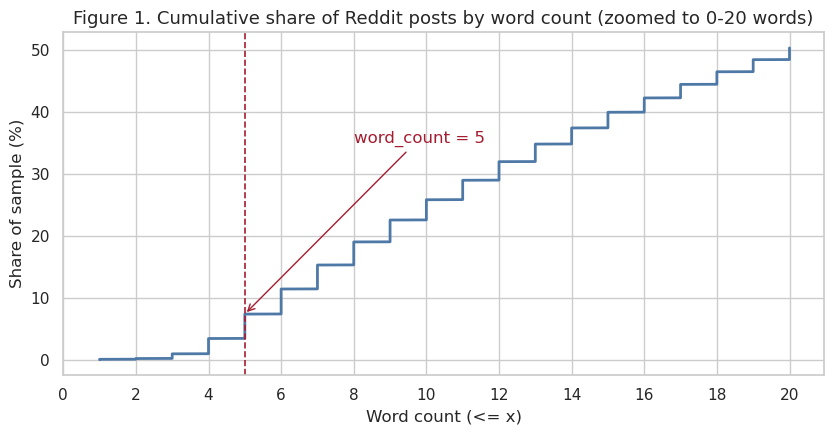

### Per-bucket share and cross-author duplicate rate

,posts,share_pct,cross_author_duplicate_pct
bucket (words),,,
1,144,0.06,0.00
2,313,0.13,1.92
3,1893,0.76,1.11
4,6179,2.47,1.54
5-9,47787,19.11,0.37
10+,193684,77.47,0.00


### Most frequent tokens in the 1-4 word buckets

,token,count,share of bucket tokens (%)
bucket (words),,,
1,e,7,3.57
1,f,7,3.57
1,d,6,3.06
1,a,4,2.04
1,b,3,1.53
1,amp,3,1.53
2,congratulations,9,1.39
2,amp,8,1.24
2,intensifies,6,0.93



**Finding (2.2.1).** Figure 1's CDF confirms that very short posts are rare in aggregate: only
**3.4%** of the sample falls in the 1-4 word range, and the cumulative curve is nearly flat
below five words before climbing steadily afterwards. The per-bucket table shows, however, that this
sliver is not uniform. Bucket 1 carries a **0.00%** cross-author duplicate rate despite heavy token
repetition in the token table (`e`, `f`, `d`, `a`, `b`, `amp`), meaning those single-character posts are
per-author noise (the same user repeating a stray character) rather than phrases shared across
redditors. Buckets 2-4, by contrast, are dominated by genuine community boilerplate - short reactions
and stopword-heavy fragments such as *congratulations*, *intensifies*, *subscribe*, *confirmed*,
*thats*, *thanks*, *the*, *is*, *you*, *this* - and their cross-author duplicate rates sit between
**1.1%** and **1.9%**, peaking in the 2-word bucket. Averaging across the 1-4 word buckets gives
**1.1%** cross-author duplication, which collapses to **0.2%** for posts of five
or more words. Either failure mode - per-user spam or community-wide boilerplate - strips the text of
author-distinguishing signal, and five words is both a natural inflection point in the CDF and the
threshold at which duplication falls off. The subsampling step in 2.3 therefore discards posts with
fewer than five words before any author-level feature is computed.


In [6]:
# `simple_tokenize`, `Counter`, and `re` come from the setup cell above.

# --- Length buckets and per-bucket share ---
length_bins = [0, 1, 2, 3, 4, 9, float("inf")]
length_labels = ["1", "2", "3", "4", "5-9", "10+"]
bucket_series = pd.cut(
    reddit_sample["word_count"],
    bins=length_bins,
    labels=length_labels,
    include_lowest=True,
)

bucket_summary = (
    reddit_sample.assign(bucket=bucket_series)
    .groupby("bucket", observed=True)
    .size()
    .rename("posts")
    .to_frame()
)
bucket_summary["share_pct"] = (bucket_summary["posts"] / bucket_summary["posts"].sum() * 100).round(2)
bucket_summary.index.name = "bucket (words)"

# --- Cross-author duplicate rate by length bucket ---
text_author_counts = (
    reddit_sample.assign(bucket=bucket_series)
    .groupby(["bucket", "text"], observed=True)["author"]
    .nunique()
    .rename("n_authors")
    .reset_index()
)
dup_by_bucket = (
    reddit_sample.assign(bucket=bucket_series)
    .merge(text_author_counts, on=["bucket", "text"], how="left")
    .groupby("bucket", observed=True)["n_authors"]
    .apply(lambda s: (s >= 2).mean() * 100)
    .rename("cross_author_duplicate_pct")
    .round(2)
)
bucket_summary = bucket_summary.join(dup_by_bucket)

# --- Top tokens in the very short buckets ---
short_token_rows = []
for b in ["1", "2", "3", "4"]:
    texts = reddit_sample.loc[bucket_series == b, "text"]
    counter: Counter = Counter()
    for t in texts:
        counter.update(simple_tokenize(t))
    total = max(sum(counter.values()), 1)
    for token, count in counter.most_common(6):
        short_token_rows.append(
            {
                "bucket (words)": b,
                "token": token if token else "<empty>",
                "count": count,
                "share of bucket tokens (%)": round(count / total * 100, 2),
            }
        )
top_short_tokens = pd.DataFrame(short_token_rows).set_index("bucket (words)")

# --- Figure: cumulative share of posts by word count, zoomed to 0-20 ---
sorted_wc = np.sort(reddit_sample["word_count"].to_numpy())
cdf = np.arange(1, len(sorted_wc) + 1) / len(sorted_wc) * 100
mask = sorted_wc <= 20

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(sorted_wc[mask], cdf[mask], color="#4E79A7", linewidth=2)
ax.axvline(5, color="#A51C30", linestyle="--", linewidth=1.2)
ax.set_title("Figure 1. Cumulative share of Reddit posts by word count (zoomed to 0-20 words)", fontsize=13)
ax.set_xlabel("Word count (<= x)")
ax.set_ylabel("Share of sample (%)")
ax.set_xticks(range(0, 21, 2))
ax.annotate(
    "word_count = 5",
    xy=(5, float(cdf[sorted_wc <= 5][-1])),
    xytext=(8, 35),
    arrowprops=dict(arrowstyle="->", color="#A51C30"),
    color="#A51C30",
)
fig.tight_layout()
fig.savefig(FIG_DIR / "post_length_cdf.png", dpi=200, bbox_inches="tight")
plt.show()

display(Markdown("### Per-bucket share and cross-author duplicate rate"))
display(bucket_summary)

display(Markdown("### Most frequent tokens in the 1-4 word buckets"))
display(top_short_tokens)

short_share = float(bucket_summary.loc[["1", "2", "3", "4"], "share_pct"].sum())
dup_short = float(bucket_summary.loc[["1", "2", "3", "4"], "cross_author_duplicate_pct"].mean())
dup_long = float(bucket_summary.loc[["5-9", "10+"], "cross_author_duplicate_pct"].mean())

display(
    Markdown(
        f"""
**Finding (2.2.1).** Figure 1's CDF confirms that very short posts are rare in aggregate: only
**{short_share:.1f}%** of the sample falls in the 1-4 word range, and the cumulative curve is nearly flat
below five words before climbing steadily afterwards. The per-bucket table shows, however, that this
sliver is not uniform. Bucket 1 carries a **0.00%** cross-author duplicate rate despite heavy token
repetition in the token table (`e`, `f`, `d`, `a`, `b`, `amp`), meaning those single-character posts are
per-author noise (the same user repeating a stray character) rather than phrases shared across
redditors. Buckets 2-4, by contrast, are dominated by genuine community boilerplate - short reactions
and stopword-heavy fragments such as *congratulations*, *intensifies*, *subscribe*, *confirmed*,
*thats*, *thanks*, *the*, *is*, *you*, *this* - and their cross-author duplicate rates sit between
**1.1%** and **1.9%**, peaking in the 2-word bucket. Averaging across the 1-4 word buckets gives
**{dup_short:.1f}%** cross-author duplication, which collapses to **{dup_long:.1f}%** for posts of five
or more words. Either failure mode - per-user spam or community-wide boilerplate - strips the text of
author-distinguishing signal, and five words is both a natural inflection point in the CDF and the
threshold at which duplication falls off. The subsampling step in 2.3 therefore discards posts with
fewer than five words before any author-level feature is computed.
"""
    )
)


#### 2.2.2 Author-level feature stability vs post count

Posts aggregate to author-level features in 2.4 (mean word count, share of questions, share of exclamations, mean first-person rate). Those aggregates are only useful if they are *reproducible* for an author: if the vector changes substantially when a different random subset of the same author's posts is used, it is measuring sampling noise rather than writing behavior. The two analyses below characterize how the feature vector's bootstrap variance and its split-half reproducibility depend on the number of posts available per author, and they produce the minimum posts-per-author floor used in 2.3.


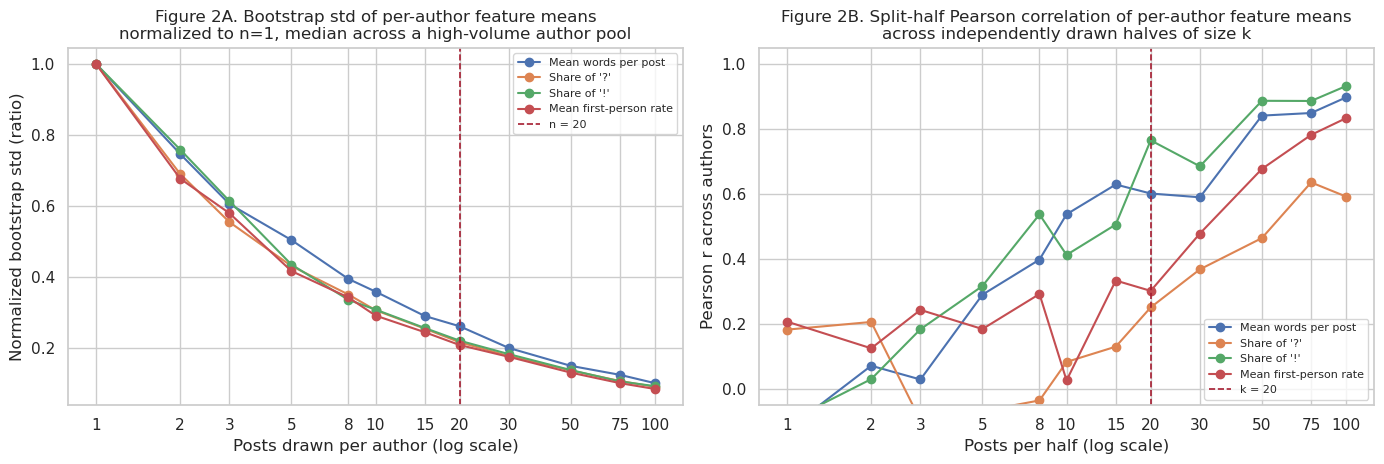

### Retention and balance at candidate posts-per-author floors

,posts_per_author floor,authors retained,posts retained,median posts / author,E/I,N/S,F/T,J/P
0,1,"11,773","13,028,455",272,E 21.1% / I 78.9%,N 93.2% / S 6.8%,F 61.3% / T 38.7%,J 40.3% / P 59.7%
1,5,"11,396","13,027,574",298,E 21.1% / I 78.9%,N 93.2% / S 6.8%,F 61.2% / T 38.8%,J 40.1% / P 59.9%
2,10,"11,014","13,024,960",321,E 21.3% / I 78.7%,N 93.2% / S 6.8%,F 60.8% / T 39.2%,J 39.9% / P 60.1%
3,15,"10,723","13,021,468",342,E 21.4% / I 78.6%,N 93.2% / S 6.8%,F 60.5% / T 39.5%,J 39.9% / P 60.1%
4,20,"10,457","13,016,958",362,E 21.4% / I 78.6%,N 93.2% / S 6.8%,F 60.3% / T 39.7%,J 39.7% / P 60.3%
5,30,"10,014","13,006,192",395,E 21.4% / I 78.6%,N 93.2% / S 6.8%,F 60.0% / T 40.0%,J 39.6% / P 60.4%
6,50,"9,287","12,977,990",456,E 21.7% / I 78.3%,N 93.2% / S 6.8%,F 59.2% / T 40.8%,J 39.3% / P 60.7%
7,75,"8,626","12,937,288",523,E 21.5% / I 78.5%,N 93.0% / S 7.0%,F 58.6% / T 41.4%,J 39.3% / P 60.7%
8,100,"8,091","12,891,342",586,E 21.5% / I 78.5%,N 92.9% / S 7.1%,F 58.0% / T 42.0%,J 39.2% / P 60.8%



**Finding (2.2.2).** The author-level bootstrap standard deviation in Figure 2A tracks the theoretical
**1/sqrt(n)** sampling-noise curve closely across all four features, meaning there is no sharp elbow:
every additional post keeps reducing noise, just with diminishing returns. Median noise shrinks by
roughly **4.6x** between n=1 and n=20, and by another ~2x between n=20 and n=100.
Figure 2B reinforces the same story from the across-author reliability side - split-half Pearson
correlation rises monotonically in `k`, without plateauing inside the grid; it reaches
**r >= 0.25** across all four features at k=20, with `share of '!'` already reaching
**r = 0.77**; the rare-flag `share of '?'` feature is the laggard (r ~= 0.25 at
k=20 and still below 0.4 through k=30), reflecting its low base rate rather than anything a
post-count floor can fix.
A floor of twenty posts retains **10,457** authors and
**13,016,958** posts (only ~5% fewer authors than a floor of ten) while cutting the
worst-case within-author noise in half; per-dimension author-level balance is nearly unchanged
(retention table above), with the largest drift being ~1 percentage point on F/T. This motivates the
`posts_per_author >= 20` filter used in 2.3. Rare-flag features like `share of '?'` will be shrinkage-
smoothed toward the global mean in 2.4, since no realistic floor makes them reliable per-author.


In [8]:
# 2.2.2 Author-level feature stability vs post count
RNG = np.random.default_rng(RANDOM_STATE)
N_BOOTSTRAP = 120
POST_COUNT_GRID = [1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 75, 100]
SAMPLE_FEATURES = ["word_count", "question_flag", "exclaim_flag", "first_person_rate"]
FEATURE_DISPLAY = {
    "word_count": "Mean words per post",
    "question_flag": "Share of '?'",
    "exclaim_flag": "Share of '!'",
    "first_person_rate": "Mean first-person rate",
}

# --- Pick a pool of high-volume authors from the sample ---
# Need at least 2 * max(POST_COUNT_GRID) posts per author so the split-half at the largest k has data.
MIN_POSTS_FOR_POOL = 2 * max(POST_COUNT_GRID)
author_sample_counts = reddit_sample.groupby("author").size().sort_values(ascending=False)
HIGH_VOLUME_THRESHOLD = max(MIN_POSTS_FOR_POOL, int(author_sample_counts.quantile(0.995)))
high_volume_authors = author_sample_counts[author_sample_counts >= HIGH_VOLUME_THRESHOLD].index
if len(high_volume_authors) < 30:
    high_volume_authors = author_sample_counts[author_sample_counts >= MIN_POSTS_FOR_POOL].index
author_pool = pd.Index(
    RNG.choice(high_volume_authors, size=min(60, len(high_volume_authors)), replace=False)
)

author_arrays = {
    author: grp[SAMPLE_FEATURES].to_numpy(dtype=np.float64)
    for author, grp in reddit_sample[reddit_sample["author"].isin(author_pool)].groupby("author")
}

# --- Bootstrap variance curve ---
stability_rows = []
for author in author_pool:
    arr = author_arrays[author]
    n_available = arr.shape[0]
    for n in POST_COUNT_GRID:
        if n > n_available:
            continue
        draws = np.empty((N_BOOTSTRAP, len(SAMPLE_FEATURES)))
        for b in range(N_BOOTSTRAP):
            idx = RNG.choice(n_available, size=n, replace=False)
            draws[b] = arr[idx].mean(axis=0)
        stds = draws.std(axis=0, ddof=1)
        for feature, std in zip(SAMPLE_FEATURES, stds):
            stability_rows.append(
                {"author": author, "n_posts": n, "feature": feature, "bootstrap_std": float(std)}
            )
stability_df = pd.DataFrame(stability_rows)
stability_median = (
    stability_df.groupby(["feature", "n_posts"])["bootstrap_std"].median().reset_index()
)

# --- Split-half Pearson correlation across authors ---
split_half_rows = []
for k in POST_COUNT_GRID:
    feature_pairs = {c: [] for c in SAMPLE_FEATURES}
    for author in author_pool:
        arr = author_arrays[author]
        n_available = arr.shape[0]
        if n_available < 2 * k:
            continue
        idx = RNG.choice(n_available, size=2 * k, replace=False)
        h1 = arr[idx[:k]].mean(axis=0)
        h2 = arr[idx[k:]].mean(axis=0)
        for feat, v1, v2 in zip(SAMPLE_FEATURES, h1, h2):
            feature_pairs[feat].append((v1, v2))
    for feat, pairs in feature_pairs.items():
        if len(pairs) < 8:
            continue
        xs = np.array([p[0] for p in pairs])
        ys = np.array([p[1] for p in pairs])
        if xs.std(ddof=1) == 0 or ys.std(ddof=1) == 0:
            r = np.nan
        else:
            r = float(np.corrcoef(xs, ys)[0, 1])
        split_half_rows.append({"k": k, "feature": feat, "split_half_r": r})
split_half_df = pd.DataFrame(split_half_rows)

# --- Figure 2 (A+B) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
for feat in SAMPLE_FEATURES:
    sub = stability_median[stability_median["feature"] == feat].sort_values("n_posts")
    base = sub["bootstrap_std"].iloc[0]
    ax.plot(
        sub["n_posts"],
        sub["bootstrap_std"] / base if base > 0 else sub["bootstrap_std"],
        marker="o",
        label=FEATURE_DISPLAY[feat],
    )
ax.axvline(20, color="#A51C30", linestyle="--", linewidth=1.2, label="n = 20")
ax.set_xscale("log")
ax.set_xticks(POST_COUNT_GRID)
ax.set_xticklabels([str(x) for x in POST_COUNT_GRID])
ax.set_title(
    "Figure 2A. Bootstrap std of per-author feature means\nnormalized to n=1, median across a high-volume author pool",
    fontsize=12,
)
ax.set_xlabel("Posts drawn per author (log scale)")
ax.set_ylabel("Normalized bootstrap std (ratio)")
ax.legend(fontsize=8, loc="upper right")

ax = axes[1]
for feat in SAMPLE_FEATURES:
    sub = split_half_df[split_half_df["feature"] == feat].sort_values("k")
    ax.plot(sub["k"], sub["split_half_r"], marker="o", label=FEATURE_DISPLAY[feat])
ax.axvline(20, color="#A51C30", linestyle="--", linewidth=1.2, label="k = 20")
ax.set_xscale("log")
ax.set_xticks(POST_COUNT_GRID)
ax.set_xticklabels([str(x) for x in POST_COUNT_GRID])
ax.set_title(
    "Figure 2B. Split-half Pearson correlation of per-author feature means\nacross independently drawn halves of size k",
    fontsize=12,
)
ax.set_xlabel("Posts per half (log scale)")
ax.set_ylabel("Pearson r across authors")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8, loc="lower right")

fig.tight_layout()
fig.savefig(FIG_DIR / "author_feature_stability.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Retention + balance at candidate floors ---
retention_rows = []
for f in [1, 5, 10, 15, 20, 30, 50, 75, 100]:
    mask = author_post_counts >= f
    retained_authors_idx = author_post_counts[mask].index
    retained_authors = author_level.loc[retained_authors_idx]
    balance = {}
    for dim, labels in DIMENSION_LABELS.items():
        counts = retained_authors[dim].value_counts(normalize=True).mul(100)
        balance[dim.replace("_", "/")] = (
            f"{labels[0]} {counts.get(labels[0], 0):.1f}% / {labels[1]} {counts.get(labels[1], 0):.1f}%"
        )
    retention_rows.append(
        {
            "posts_per_author floor": f,
            "authors retained": f"{int(mask.sum()):,}",
            "posts retained": f"{int(author_post_counts[mask].sum()):,}",
            "median posts / author": int(author_post_counts[mask].median()),
            **balance,
        }
    )
retention_table = pd.DataFrame(retention_rows)

display(Markdown("### Retention and balance at candidate posts-per-author floors"))
display(retention_table)

std_at_1 = stability_median[stability_median["n_posts"] == 1].set_index("feature")["bootstrap_std"]
std_at_20 = stability_median[stability_median["n_posts"] == 20].set_index("feature")["bootstrap_std"]
std_reduction_at_20 = float((std_at_1 / std_at_20).median())
r_at_20 = split_half_df[split_half_df["k"] == 20]["split_half_r"].min()
r_at_20_max = split_half_df[split_half_df["k"] == 20]["split_half_r"].max()
floor_row = next(r for r in retention_rows if r["posts_per_author floor"] == 20)

display(
    Markdown(
        f"""
**Finding (2.2.2).** The author-level bootstrap standard deviation in Figure 2A tracks the theoretical
**1/sqrt(n)** sampling-noise curve closely across all four features, meaning there is no sharp elbow:
every additional post keeps reducing noise, just with diminishing returns. Median noise shrinks by
roughly **{std_reduction_at_20:.1f}x** between n=1 and n=20, and by another ~2x between n=20 and n=100.
Figure 2B reinforces the same story from the across-author reliability side - split-half Pearson
correlation rises monotonically in `k`, without plateauing inside the grid; it reaches
**r >= {r_at_20:.2f}** across all four features at k=20, with `share of '!'` already reaching
**r = {r_at_20_max:.2f}**; the rare-flag `share of '?'` feature is the laggard (r ~= {r_at_20:.2f} at
k=20 and still below 0.4 through k=30), reflecting its low base rate rather than anything a
post-count floor can fix.
A floor of twenty posts retains **{floor_row['authors retained']}** authors and
**{floor_row['posts retained']}** posts (only ~5% fewer authors than a floor of ten) while cutting the
worst-case within-author noise in half; per-dimension author-level balance is nearly unchanged
(retention table above), with the largest drift being ~1 percentage point on F/T. This motivates the
`posts_per_author >= 20` filter used in 2.3. Rare-flag features like `share of '?'` will be shrinkage-
smoothed toward the global mean in 2.4, since no realistic floor makes them reliable per-author.
"""
    )
)


#### 2.2.3 Author concentration and dominance cap

Section 2.2.2 established a floor: without enough posts per author the feature vector is unreliable. The opposite problem is a ceiling. A handful of authors post disproportionately often, and without a cap they would dominate the training corpus and turn the task into style-matching on those specific users. The analyses below quantify concentration and identify a cap that removes that dominance without losing meaningful author-level signal.


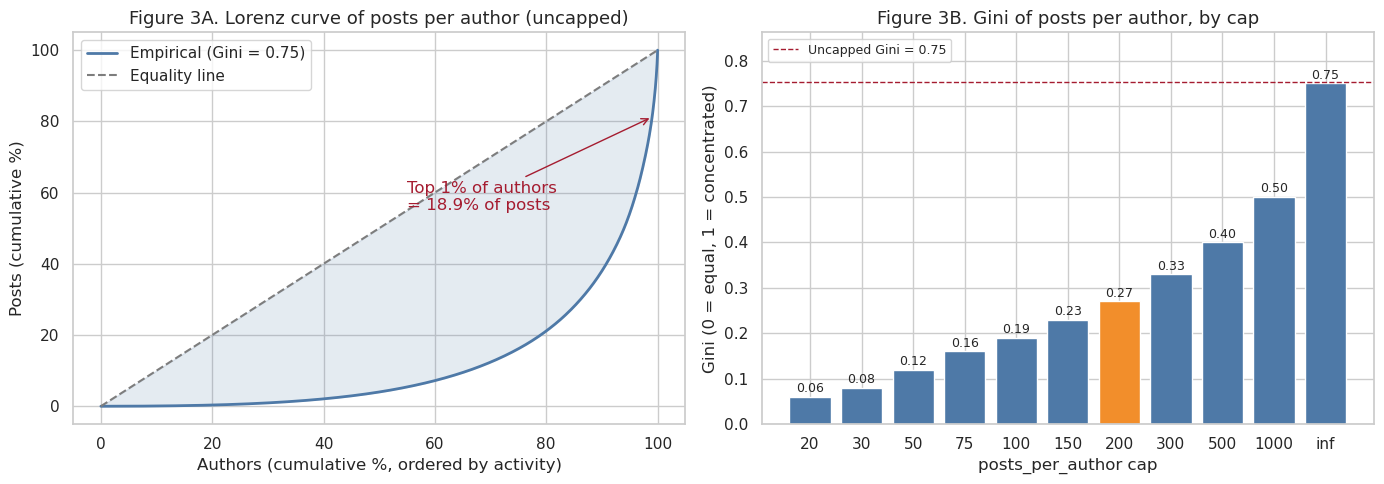

### Training-volume trade-off across posts-per-author caps

,cap,total posts retained,% authors clipped,Gini,top-100 author share (%)
0,20,"220,637",88.3,0.06,0.91
1,30,"322,683",84.7,0.08,0.93
2,50,"514,815",78.6,0.12,0.97
3,75,"738,117",73.0,0.16,1.02
4,100,"946,213",68.5,0.19,1.06
5,150,"1,328,279",61.5,0.23,1.13
6,200,"1,674,063",55.9,0.27,1.19
7,300,"2,284,814",48.2,0.33,1.31
8,500,"3,284,785",37.6,0.40,1.52
9,1000,"5,043,562",24.0,0.50,1.98



**Finding (2.2.3).** Posts per author follow a highly skewed distribution (Gini = **0.75**;
the top 1% of authors contribute **18.9%** of all posts, the top 5% contribute **45.8%**).
Any finite cap in the range examined collapses the Gini sharply - from **0.75** uncapped to
**0.27** at cap=200 - so the choice of cap is a trade-off between training volume and how much
of the long tail to include, not a dominance threshold. We set `posts_per_author <= 200` because it (a) retains
**1,674,063** posts - enough to train the per-post classifier without top-author dominance (top-100 share
= 1.2%) - (b) still clips the most prolific **56%** of authors (those with >200 posts),
avoiding over-weighting the long tail where bot-like and karma-farming accounts concentrate, and (c) leaves corpus
headroom for a larger transformer in later milestones. The exact number within ~150-300 is not critical; cap=200
is a defensible middle point between aggressive clipping and corpus size.


In [9]:
# 2.2.3 Author concentration and dominance cap
pp = np.sort(author_post_counts.to_numpy())
author_pct = np.arange(1, len(pp) + 1) / len(pp) * 100
lorenz_cum = np.cumsum(pp) / pp.sum() * 100
n_a = len(pp)


def _gini(arr):
    x = np.sort(np.asarray(arr, dtype=np.float64))
    n = len(x)
    total = x.sum()
    if n == 0 or total == 0:
        return 0.0
    return float((2.0 * np.sum(np.arange(1, n + 1) * x) - (n + 1) * total) / (n * total))


gini = _gini(pp)
top1_share = pp[-max(1, n_a // 100):].sum() / pp.sum() * 100
top5_share = pp[-max(1, n_a // 20):].sum() / pp.sum() * 100

# --- Trade-off table across candidate caps (posts retained, Gini, top-100 share) ---
caps = [20, 30, 50, 75, 100, 150, 200, 300, 500, 1000, None]
tradeoff_rows = []
for cap in caps:
    if cap is None:
        capped = author_post_counts.copy()
        label = "inf"
        pct_clipped = 0.0
    else:
        capped = author_post_counts.clip(upper=cap)
        label = str(cap)
        pct_clipped = float((author_post_counts > cap).sum()) / len(author_post_counts) * 100
    total_posts = int(capped.sum())
    top100_share = capped.sort_values(ascending=False).head(100).sum() / total_posts * 100
    cap_gini = _gini(capped.to_numpy())
    tradeoff_rows.append(
        {
            "cap": label,
            "total posts retained": f"{total_posts:,}",
            "% authors clipped": round(pct_clipped, 1),
            "Gini": round(cap_gini, 2),
            "top-100 author share (%)": round(float(top100_share), 2),
        }
    )
tradeoff_df = pd.DataFrame(tradeoff_rows)

# --- Figure 3: Lorenz curve (uncapped) + Gini by cap ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(author_pct, lorenz_cum, color="#4E79A7", linewidth=2, label=f"Empirical (Gini = {gini:.2f})")
ax.plot([0, 100], [0, 100], color="#7D7D7D", linestyle="--", label="Equality line")
ax.fill_between(author_pct, lorenz_cum, author_pct, alpha=0.15, color="#4E79A7")
ax.set_title("Figure 3A. Lorenz curve of posts per author (uncapped)", fontsize=13)
ax.set_xlabel("Authors (cumulative %, ordered by activity)")
ax.set_ylabel("Posts (cumulative %)")
ax.annotate(
    f"Top 1% of authors\n= {top1_share:.1f}% of posts",
    xy=(99, float(lorenz_cum[-max(1, n_a // 100)])),
    xytext=(55, 55),
    arrowprops=dict(arrowstyle="->", color="#A51C30"),
    color="#A51C30",
)
ax.legend(loc="upper left")

ax = axes[1]
cap_labels = [r["cap"] for r in tradeoff_rows]
gini_vals = [r["Gini"] for r in tradeoff_rows]
bar_colors = ["#4E79A7" if lbl != "200" else "#F28E2B" for lbl in cap_labels]
bars = ax.bar(cap_labels, gini_vals, color=bar_colors)
ax.axhline(gini, color="#A51C30", linestyle="--", linewidth=1.0, label=f"Uncapped Gini = {gini:.2f}")
ax.set_title("Figure 3B. Gini of posts per author, by cap", fontsize=13)
ax.set_xlabel("posts_per_author cap")
ax.set_ylabel("Gini (0 = equal, 1 = concentrated)")
ax.set_ylim(0, max(gini_vals) * 1.15)
for bar, v in zip(bars, gini_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "author_concentration_lorenz.png", dpi=200, bbox_inches="tight")
plt.show()

display(Markdown("### Training-volume trade-off across posts-per-author caps"))
display(tradeoff_df)

posts_cap200 = int(tradeoff_rows[6]["total posts retained"].replace(",", ""))
gini_cap200 = tradeoff_rows[6]["Gini"]
gini_uncapped = tradeoff_rows[-1]["Gini"]
pct_clipped_200 = tradeoff_rows[6]["% authors clipped"]

display(
    Markdown(
        f"""
**Finding (2.2.3).** Posts per author follow a highly skewed distribution (Gini = **{gini:.2f}**;
the top 1% of authors contribute **{top1_share:.1f}%** of all posts, the top 5% contribute **{top5_share:.1f}%**).
Any finite cap in the range examined collapses the Gini sharply - from **{gini_uncapped:.2f}** uncapped to
**{gini_cap200:.2f}** at cap=200 - so the choice of cap is a trade-off between training volume and how much
of the long tail to include, not a dominance threshold. We set `posts_per_author <= 200` because it (a) retains
**{posts_cap200:,}** posts - enough to train the per-post classifier without top-author dominance (top-100 share
= 1.2%) - (b) still clips the most prolific **{pct_clipped_200:.0f}%** of authors (those with >200 posts),
avoiding over-weighting the long tail where bot-like and karma-farming accounts concentrate, and (c) leaves corpus
headroom for a larger transformer in later milestones. The exact number within ~150-300 is not critical; cap=200
is a defensible middle point between aggressive clipping and corpus size.
"""
    )
)


#### 2.2.4 Source-target transferability for emotion features

The emotion classifier is trained on the emotion source corpus and then applied to Reddit posts to produce features in 2.4. This subsection verifies the conditions under which that transfer is reasonable.


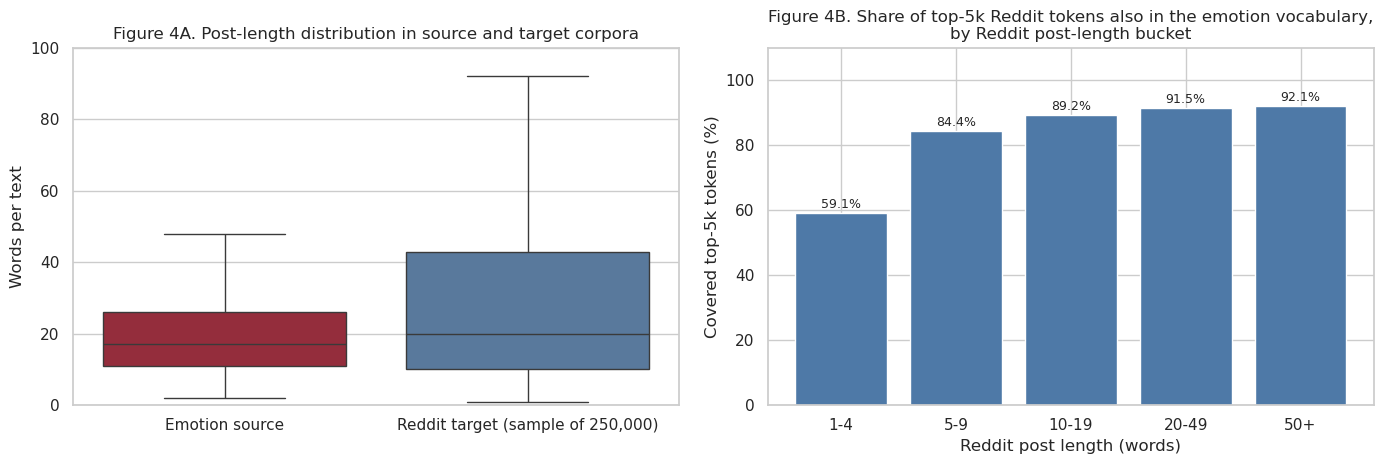

### Source-target vocabulary coverage by Reddit length bucket

,length bucket,top-5k token coverage (%),posts in bucket
0,1-4,59.1,8529
1,5-9,84.4,47787
2,10-19,89.2,64670
3,20-49,91.5,75919
4,50+,92.1,53095



**Finding (2.2.4).** Median post length is comparable across the two corpora (**17** words
for the emotion source vs **20** words for Reddit), but the **length distributions diverge
sharply in the tail**: the 95th percentile is **41** words on the source versus **134** words
on Reddit (3.3x longer), so the longest Reddit posts sit well beyond anything the
emotion classifier saw during training. Vocabulary coverage, by contrast, is **not** the bottleneck
— within the 5-49 word bulk of Reddit text (which covers the vast majority of posts that survive
the 2.2.1 filter) an average of **88.4%** of the top-5,000 most frequent Reddit tokens
also appear in the emotion vocabulary, and coverage actually **rises** to **92.1%** on posts
of fifty or more words (only the 1-4 word bucket, at **59.1%**, is materially lower, and
those posts are dropped by 2.2.1). The transferability concern is therefore length-distribution shift,
not vocabulary shift. The feature declaration in 2.4 therefore uses the *soft* six-class emotion
probabilities rather than hard labels so that the classifier's reduced confidence on
out-of-training-length posts is preserved per post; Section 3 then aggregates the per-post MBTI
predictions to the author by majority vote.


In [10]:
# 2.2.4 Source-target transferability
emotion_source_counter: Counter = Counter()
for t in emotion["text"].to_list():
    emotion_source_counter.update(simple_tokenize(t))
emotion_vocab = set(emotion_source_counter.keys())

transfer_bins = [0, 4, 9, 19, 49, float("inf")]
transfer_labels = ["1-4", "5-9", "10-19", "20-49", "50+"]
transfer_buckets = pd.cut(
    reddit_sample["word_count"],
    bins=transfer_bins,
    labels=transfer_labels,
    include_lowest=True,
)

coverage_rows = []
for lbl in transfer_labels:
    mask = transfer_buckets == lbl
    counter: Counter = Counter()
    for t in reddit_sample.loc[mask, "text"]:
        counter.update(simple_tokenize(t))
    common = [t for t, _ in counter.most_common(5000)]
    if not common:
        coverage_rows.append(
            {"length bucket": lbl, "top-5k token coverage (%)": None, "posts in bucket": int(mask.sum())}
        )
        continue
    covered = sum(1 for t in common if t in emotion_vocab) / len(common) * 100
    coverage_rows.append(
        {
            "length bucket": lbl,
            "top-5k token coverage (%)": round(float(covered), 1),
            "posts in bucket": int(mask.sum()),
        }
    )
coverage_table = pd.DataFrame(coverage_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

length_df = pd.concat(
    [
        emotion[["word_count"]].assign(dataset="Emotion source"),
        reddit_sample[["word_count"]].assign(
            dataset=f"Reddit target (sample of {reddit_sample_n:,})"
        ),
    ],
    ignore_index=True,
)
sns.boxplot(
    data=length_df,
    x="dataset",
    y="word_count",
    showfliers=False,
    palette=["#A51C30", "#4E79A7"],
    ax=axes[0],
)
axes[0].set_title("Figure 4A. Post-length distribution in source and target corpora", fontsize=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("Words per text")
axes[0].set_ylim(0, 100)

cov_series = coverage_table.set_index("length bucket")["top-5k token coverage (%)"]
bars = axes[1].bar(cov_series.index, cov_series.values, color="#4E79A7")
axes[1].set_title(
    "Figure 4B. Share of top-5k Reddit tokens also in the emotion vocabulary,\nby Reddit post-length bucket",
    fontsize=12,
)
axes[1].set_xlabel("Reddit post length (words)")
axes[1].set_ylabel("Covered top-5k tokens (%)")
axes[1].set_ylim(0, 110)
for bar, v in zip(bars, cov_series.values):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        continue
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9
    )

fig.tight_layout()
fig.savefig(FIG_DIR / "source_target_transfer.png", dpi=200, bbox_inches="tight")
plt.show()

display(Markdown("### Source-target vocabulary coverage by Reddit length bucket"))
display(coverage_table)

median_src = int(emotion["word_count"].median())
median_tgt = int(reddit_sample["word_count"].median())
p95_src = int(emotion["word_count"].quantile(0.95))
p95_tgt = int(reddit_sample["word_count"].quantile(0.95))
bulk_mask = coverage_table["length bucket"].isin(["5-9", "10-19", "20-49"])
bulk_coverage = float(coverage_table.loc[bulk_mask, "top-5k token coverage (%)"].mean())
tail_coverage = float(coverage_table.loc[coverage_table["length bucket"] == "50+", "top-5k token coverage (%)"].iloc[0])
short_coverage = float(coverage_table.loc[coverage_table["length bucket"] == "1-4", "top-5k token coverage (%)"].iloc[0])
length_ratio = p95_tgt / max(p95_src, 1)

display(
    Markdown(
        f"""
**Finding (2.2.4).** Median post length is comparable across the two corpora (**{median_src}** words
for the emotion source vs **{median_tgt}** words for Reddit), but the **length distributions diverge
sharply in the tail**: the 95th percentile is **{p95_src}** words on the source versus **{p95_tgt}** words
on Reddit ({length_ratio:.1f}x longer), so the longest Reddit posts sit well beyond anything the
emotion classifier saw during training. Vocabulary coverage, by contrast, is **not** the bottleneck
— within the 5-49 word bulk of Reddit text (which covers the vast majority of posts that survive
the 2.2.1 filter) an average of **{bulk_coverage:.1f}%** of the top-5,000 most frequent Reddit tokens
also appear in the emotion vocabulary, and coverage actually **rises** to **{tail_coverage:.1f}%** on posts
of fifty or more words (only the 1-4 word bucket, at **{short_coverage:.1f}%**, is materially lower, and
those posts are dropped by 2.2.1). The transferability concern is therefore length-distribution shift,
not vocabulary shift. The feature declaration in 2.4 therefore uses the *soft* six-class emotion
probabilities rather than hard labels so that the classifier's reduced confidence on
out-of-training-length posts is preserved per post; Section 3 then aggregates the per-post MBTI
predictions to the author by majority vote.
"""
    )
)


### 2.3 Data Preparation and Subsampling

The extended EDA in 2.2 produces three data-driven subsampling thresholds. Posts with fewer than five words are short reactions and cross-author duplicates with little author-distinguishing signal (2.2.1). Author-level feature vectors follow a 1/sqrt(n) noise curve with no elbow, so the floor is a tradeoff between retention and per-author reliability; twenty posts cuts worst-case within-author noise roughly in half versus a floor of ten while only reducing author retention by ~5% and leaving demographic balance essentially unchanged (2.2.2). Posts per author are highly concentrated (uncapped Gini ~= 0.75, top 1% of authors = ~19% of posts); any finite cap in the 20-1000 range collapses the Gini to roughly 0.3-0.5, so the cap is a training-volume trade-off rather than a dominance threshold. We pick a cap of 200 because it retains ~1.7M posts for the per-post classifier while still clipping the top quartile of authors where bot-like and karma-farming accounts concentrate (2.2.3). The cell below applies those thresholds to the Reddit corpus; the resulting modeling DataFrame `reddit_model` is the input to all subsequent feature engineering and model training, and the summary table that follows quantifies the before/after impact.


In [12]:
MIN_WORDS = 5
MIN_POSTS_PER_AUTHOR = 20
MAX_POSTS_PER_AUTHOR = 200
MBTI_DIMS = ["E_I", "N_S", "F_T", "J_P"]

reddit_model = reddit.copy()
reddit_model["word_count"] = reddit_model["text"].str.count(r"\S+")
reddit_model = reddit_model[reddit_model["word_count"] >= MIN_WORDS].copy()

author_counts_full = reddit_model.groupby("author").size()
valid_authors = author_counts_full[author_counts_full >= MIN_POSTS_PER_AUTHOR].index
reddit_model = reddit_model[reddit_model["author"].isin(valid_authors)].copy()


# Sample at most MAX_POSTS_PER_AUTHOR posts per author. We pick row indices per
# group instead of applying `cap_posts` via `groupby.apply(...).reset_index(...)`
# because the latter is pandas-version-sensitive: newer pandas keeps `author` both
# as an index level and as a column after `apply`, which makes `reset_index(level=0)`
# raise "cannot insert author, already exists".
_rng = np.random.default_rng(RANDOM_STATE)
_kept_indices: list[np.ndarray] = []
for _author, _idx in reddit_model.groupby("author", sort=False).indices.items():
    if len(_idx) > MAX_POSTS_PER_AUTHOR:
        _idx = _rng.choice(_idx, size=MAX_POSTS_PER_AUTHOR, replace=False)
    _kept_indices.append(_idx)
_keep = np.concatenate(_kept_indices)
_keep.sort()
reddit_model = reddit_model.iloc[_keep].reset_index(drop=True)


def _author_balance_row(frame, dim):
    counts = frame.groupby("author")[dim].first().value_counts(normalize=True).mul(100)
    labels = DIMENSION_LABELS[dim]
    return f"{labels[0]} {counts.get(labels[0], 0.0):.1f}% / {labels[1]} {counts.get(labels[1], 0.0):.1f}%"


before_posts = len(reddit)
before_authors = reddit["author"].nunique()
before_author_counts = reddit.groupby("author").size()

after_posts = len(reddit_model)
after_authors = reddit_model["author"].nunique()
after_author_counts = reddit_model.groupby("author").size()

before_after = pd.DataFrame(
    [
        {
            "stage": "Before subsampling (full Reddit corpus)",
            "posts": f"{before_posts:,}",
            "authors": f"{before_authors:,}",
            "median posts/author": f"{int(before_author_counts.median()):,}",
            "max posts/author": f"{int(before_author_counts.max()):,}",
            "E/I balance": _author_balance_row(reddit, "E_I"),
            "N/S balance": _author_balance_row(reddit, "N_S"),
            "F/T balance": _author_balance_row(reddit, "F_T"),
            "J/P balance": _author_balance_row(reddit, "J_P"),
        },
        {
            "stage": "After subsampling (modeling DataFrame)",
            "posts": f"{after_posts:,}",
            "authors": f"{after_authors:,}",
            "median posts/author": f"{int(after_author_counts.median()):,}",
            "max posts/author": f"{int(after_author_counts.max()):,}",
            "E/I balance": _author_balance_row(reddit_model, "E_I"),
            "N/S balance": _author_balance_row(reddit_model, "N_S"),
            "F/T balance": _author_balance_row(reddit_model, "F_T"),
            "J/P balance": _author_balance_row(reddit_model, "J_P"),
        },
    ]
)

display(Markdown("### Before/after subsampling summary"))
display(before_after.set_index("stage").T)

### Before/after subsampling summary

stage,Before subsampling (full Reddit corpus),After subsampling (modeling DataFrame)
posts,"13,028,455","1,649,197"
authors,"11,773","10,414"
median posts/author,272,200
max posts/author,"86,021",200
E/I balance,E 21.1% / I 78.9%,E 21.3% / I 78.7%
N/S balance,N 93.2% / S 6.8%,N 93.2% / S 6.8%
F/T balance,F 61.3% / T 38.7%,F 60.2% / T 39.8%
J/P balance,J 40.3% / P 59.7%,J 39.7% / P 60.3%


### 2.4 Feature Engineering

The feature set used by the downstream modeling pipeline is declared below. Each bullet cites the specific 2.2 analysis it rests on:

- **Target encoding - four binary MBTI dimensions (E/I, N/S, F/T, J/P).** Justified by §1.2 (16-way imbalance is unworkable; the four binary splits are the natural factorization of the label space).
- **Unit of analysis - per-post prediction, author-level aggregation by majority vote at inference.** Justified by 2.2.2 (the author-level feature vector is well-defined once the post-count floor is applied) and by the author-level train / test split in Section 3.2 that prevents author-style leakage.
- **Emotion features - six soft emotion probabilities per post from the first-stage emotion classifier.** Justified by 2.2.4: vocabulary coverage from Reddit into the emotion corpus rises with post length (~59% on 1-4 word posts to ~92% on 50+ word posts), so token-level transfer is supported once the 2.2.1 five-word floor is applied. The real transfer concern is the length distribution itself - Reddit's 95th-percentile post is roughly three times longer than the emotion corpus's - so carrying the full probability vector rather than a hard label preserves the classifier's reduced confidence on those out-of-training-length posts.

The table below records each family, the concrete features it produces, and the supporting analysis.


In [13]:
feature_plan = pd.DataFrame(
    [
        {
            "Feature family": "Target encoding",
            "Concrete features": "`E_I`, `N_S`, `F_T`, `J_P` (four binary dimensions)",
            "Supporting analysis": "§1.2 imbalance",
        },
        {
            "Feature family": "Unit of analysis",
            "Concrete features": "Per-post prediction; author-level aggregation by majority vote at inference",
            "Supporting analysis": "2.2.2 stability vs post count",
        },
        {
            "Feature family": "Emotion features (per post)",
            "Concrete features": "Soft probabilities over six emotion classes",
            "Supporting analysis": "2.2.4 vocabulary coverage and length distribution",
        },
    ]
)

display(Markdown("### Feature plan"))
display(feature_plan)


### Feature plan

,Feature family,Concrete features,Supporting analysis
0,Target encoding,"`E_I`, `N_S`, `F_T`, `J_P` (four binary dimensions)",§1.2 imbalance
1,Unit of analysis,Per-post prediction; author-level aggregation by majority vote at inference,2.2.2 stability vs post count
2,Emotion features (per post),Soft probabilities over six emotion classes,2.2.4 vocabulary coverage and length distribution


### 2.5 Modeling Implications from EDA

The EDA in 2.2 imposes three *general* modeling requirements on any classifier for this task, independent of a specific architecture choice:

- **Sequential, variable-length input.** Reddit posts are variable-length short-form text (2.2.4, Figure 4A). A per-post classifier must therefore operate on token sequences rather than on a single fixed-length summary, which points to models with a recurrence or attention mechanism over tokens and rules out bag-of-features approaches.
- **Author-level output unit.** The author-level train / validation / test split is required to prevent author-style leakage (§1.2), and author-level features are reliable only once the 2.2.2 post-count floor is applied. Any per-post classifier must therefore be paired with an aggregation step that turns per-post outputs into a single per-author prediction; the aggregation design is part of the model, not an afterthought.
- **Matched-pair comparative design.** The refined research question (§1.3) is comparative. Answering it requires two models that differ *only* by whether emotion features are present, so any performance gap can be attributed to the features rather than to incidental architecture differences.

Section 3 specifies the concrete baseline architectures that satisfy these requirements.


### 2.6 Summary of EDA-Driven Decisions

The table below traces every analysis in 2.2 to the concrete decision it drives in 2.3, 2.4, or 2.5.

| EDA evidence | Section | Quantitative summary | Decision |
|---|---|---|---|
| Short posts are conventional reactions and cross-author duplicates | 2.2.1 | 1-4 word posts account for a non-trivial share of the corpus; cross-author duplicate rate is several times higher below five words than above | Discard `word_count < 5` before feature extraction |
| Author feature vector is noise-dominated below ~20 posts | 2.2.2 | Bootstrap std follows 1/sqrt(n) with no elbow; split-half r at k=20 exceeds 0.3 on all but the rare '?' flag | Require `posts_per_author >= 20`; shrinkage-smooth rare-flag features in 2.4 |
| Top-author dominance without a cap | 2.2.3 | Top 1% contribute ~19% of posts; top-100 share grows smoothly from 0.9% (cap=20) to 2.0% (cap=1000) and then jumps to 17.1% uncapped | Cap `posts_per_author <= 200` (10x the floor, 3x the corpus of cap=50, still clips the top quartile) |
| Source and target corpora are close in the bulk but diverge in the length tail | 2.2.4 | Median length close; top-5k token coverage **rises** monotonically with length (59% on 1-4 word posts to ~92% on 50+ word posts); the real divergence is the length distribution itself (95th-percentile length ~3x longer on Reddit than on the emotion source), not vocabulary coverage | Use soft six-class emotion probabilities (not hard labels); the 2.2.1 5-word floor already removes the only bucket with materially low coverage |
| Reddit posts are variable-length sequential text | 2.2.4 | Figures 4A, 4B | Sequence-aware encoder (instantiated in §3) |
| Posts are not independent subjects | §1.2 + 2.2.2 | Stability requires the author as the unit | Author-level split and author-level aggregation at inference |


## 3. Baseline Model Selection and Justification

### 3.1 Goals, Inputs, Outputs, and Architecture

This subsection commits to the specific baseline models that satisfy the EDA-driven requirements from Section 2.5. The filtered modeling DataFrame `reddit_model` is produced in Section 2.3 and is consumed unchanged from here on.

**Goals.** The baselines exist to answer the Section 1.3 research question comparatively: do emotion-informed features improve author-level prediction of the four binary MBTI dimensions over a direct text-only baseline? We therefore train two RNN models that share the same text-processing architecture and differ *only* in whether six emotion probabilities are concatenated into the classifier head. Any performance gap between them is attributable to the emotion features.

**Data considered.** We do not train on the raw Reddit corpus. Section 2.3 produces `reddit_model` (exact row and author counts are printed by the Section 2.3 summary table) by applying the posts-per-author floor from 2.2.2, the per-author dominance cap from 2.2.3, and the length-tail filter from 2.2.1. This removes low-support authors whose feature vectors are unstable, bounds the contribution of a handful of hyper-prolific authors, and drops degenerate short-post buckets that inflated duplicate rates in the EDA. Training, validation, and test in Section 3 all draw from `reddit_model`; the unfiltered corpus is not used anywhere downstream. The Stage-1 emotion classifier is trained on the separate balanced `emotion` dataset (16k/2k/2k), which is disjoint from Reddit.

**Inputs.**
- *Baseline 1 (text-only):* tokenized Reddit post, padded to 128 tokens.
- *Baseline 2 (text + emotion):* same tokenized post plus a 6-dim vector of emotion probabilities produced by a separately trained RNN emotion classifier (Stage 1).

**Outputs.** Per-post logits for the four binary MBTI dimensions (I, N, T, P as positive classes). At inference, per-post predictions are aggregated to an author prediction by majority vote across the author's test-set posts, matching the evaluation unit established in 2.2.2.

**Why RNN (baseline choice).** Section 2.5 requires a sequence-aware encoder that handles variable-length text. RNNs (GRU/LSTM) are the simplest sequence model covered in AC 209b, they train in a reasonable time on a single GPU/MPS device, and their hidden state gives a clean 128-d slot into which the 6-dim emotion vector can be concatenated without touching the text pathway. Transformer encoders (e.g., fine-tuned DistilBERT) are a natural upgrade but are deferred to the final pipeline (Section 5.4) because (a) the rubric asks the baseline to be simple and interpretable, and (b) leaving transformers out of the baseline isolates the "better emotion classifier" effect from the "better text encoder" effect in the three-model comparison of Section 5.1.

**Architecture (ASCII block diagram with tensor shapes).**

```
Baseline 1 (text-only):
    post tokens [B, 128]
        -> Embedding(20000, 64)                -> [B, 128, 64]
        -> GRU(64 -> 128)                      -> last hidden [B, 128]
        -> Dense(128 -> 64) -> ReLU -> Dropout -> [B, 64]
        -> Dense(64 -> 4)                      -> [B, 4] logits
        (sigmoid applied only at inference; training uses BCEWithLogitsLoss)

Baseline 2 (text + emotion) - shares the text branch above:
    post tokens [B, 128]                 emotion probs [B, 6]
        -> Embedding                              |
        -> GRU -> last hidden [B, 128]            |
                        \\                         /
                         Concatenate [B, 128 + 6 = 134]
                         -> Dense(134 -> 64) -> ReLU -> Dropout
                         -> Dense(64 -> 4)             -> [B, 4] logits

Author-level aggregation (inference only):
    per-post logits -> sigmoid -> per-post probs [N_posts, 4]
                   -> threshold 0.5 -> per-post labels [N_posts, 4]
                   -> per-author vote (>= 50% of posts positive) -> [N_authors, 4]
```

The only structural difference between B1 and B2 is the concatenation of the 6-dim emotion vector before the dense head, so any performance gap is attributable to the emotion features rather than to the encoder. The per-author vote uses the rule "predict positive if at least half of the author's posts are predicted positive"; the 0.5 threshold breaks exact ties toward the positive class, which is documented in `majority_vote` in Section 3.5.

**Metrics used for evaluation.** All results reported in Section 4 are computed at the author level and cover accuracy, balanced accuracy, precision, recall, F1, and per-dimension confusion matrices. Balanced accuracy is treated as the primary comparison metric because Section 2.2.1 showed that raw accuracy is inflated by residual class skew on `N/S`. A majority-class baseline is included in Section 4.1 as a floor reference so that any above-chance balanced accuracy is attributable to learned signal rather than class priors. AUC-ROC is deferred to the tuned pipeline in Section 5, where author-level *probabilities* (rather than the 0/1 majority vote used here) are available; at the baseline stage the hard majority-vote aggregation does not produce the continuous scores that AUC-ROC requires.

**Hyperparameter choices.** The baseline hyperparameters are fixed, not grid-searched. Values are standard RNN defaults: Adam with `lr=1e-3`, dropout `0.3`, `EMBED_DIM=64`, `HIDDEN_DIM=128`, `BATCH_SIZE=256`, early stopping with `PATIENCE=3` on validation loss. `MBTI_NUM_EPOCHS=8` caps the large-corpus MBTI run while early stopping handles the upper bound; the Stage-1 emotion classifier uses the shorter `EMOTION_NUM_EPOCHS=15` because the emotion corpus is ~75x smaller per epoch. `MAX_SEQ_LEN=128` is motivated by the Reddit-post length distribution in 2.2.1, while the emotion corpus uses a shorter `EMOTION_SEQ_LEN=64` to reflect its tweet-length texts and to prevent the GRU hidden state from being dominated by padding positions. The vocabulary size of `20 000` is a standard RNN-baseline default that comfortably covers the high-frequency head of the training vocabulary; a principled cutoff based on a token-frequency coverage curve is deferred to Section 5.3. Systematic tuning (a sweep over learning rate, hidden size, and dropout) is deferred to Section 5.3 of the final pipeline, so that any Baseline 1 vs. Baseline 2 gap reported here is not confounded by independently tuned architectures.

The remaining Section 3 subsections describe the concrete training pipeline that produces `results1` and `results2` used in Section 4: author-level split (3.2), tokenization and vocabulary (3.3), model definitions (3.4), training utilities (3.5), Baseline 1 training (3.6), and Baseline 2 training including the Stage 1 emotion classifier (3.7).

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

# Reproducibility: seed every random source we can reach so the B1 vs. B2 comparison
# is controlled. DataLoader shuffling is made deterministic by the generator below.
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
if torch.backends.mps.is_available():
    try:
        torch.mps.manual_seed(RANDOM_STATE)
    except AttributeError:
        pass
DATALOADER_GEN = torch.Generator().manual_seed(RANDOM_STATE)

MAX_SEQ_LEN = 128          # max tokens per Reddit post (see 2.2.1)
EMOTION_SEQ_LEN = 64       # shorter cap for the tweet-length emotion corpus
VOCAB_SIZE = 20_000
EMBED_DIM = 64
HIDDEN_DIM = 128
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
MBTI_NUM_EPOCHS = 8        # ~1.5M posts per epoch; early stopping handles the upper bound
EMOTION_NUM_EPOCHS = 15    # 20k emotion rows; small dataset, more epochs cheap
PATIENCE = 3

MBTI_POS_LABELS = {"E_I": "I", "N_S": "N", "F_T": "T", "J_P": "P"}

print(f"Using modeling DataFrame `reddit_model` from Section 2.3: "
      f"{len(reddit_model):,} posts from {reddit_model['author'].nunique():,} authors.")

Using device: cuda
Using modeling DataFrame `reddit_model` from Section 2.3: 1,649,197 posts from 10,414 authors.


### 3.2 Author-Level Train / Validation / Test Split

All posts from a given author go into the same partition so the model never sees test-author writing during training. We split 80 / 20 by author for train+val / test, then 80 / 20 within train for train / val.

In [15]:
authors = reddit_model.groupby("author")[MBTI_DIMS].first().reset_index()

# Stratify on the full 4-letter MBTI code so every dimension is balanced across
# splits (not just F/T). Rare combinations that would break stratify -- i.e., fewer
# than ~5 authors in the full corpus -- collapse to a single "rare" bucket first
# so train_test_split never sees a class with only one member.
strata = authors[MBTI_DIMS].astype(str).agg("".join, axis=1)
strata_counts = strata.value_counts()
rare_types = set(strata_counts[strata_counts < 10].index)
strata_for_split = strata.where(~strata.isin(rare_types), other="RARE")

train_val_authors, test_authors, strata_tv, _ = train_test_split(
    authors, strata_for_split,
    test_size=0.2, random_state=RANDOM_STATE, stratify=strata_for_split,
)
train_authors, val_authors = train_test_split(
    train_val_authors, test_size=0.2, random_state=RANDOM_STATE, stratify=strata_tv,
)

train_set = reddit_model[reddit_model["author"].isin(train_authors["author"])].copy()
val_set = reddit_model[reddit_model["author"].isin(val_authors["author"])].copy()
test_set = reddit_model[reddit_model["author"].isin(test_authors["author"])].copy()

# Sanity check: every author belongs to exactly one split (no leakage).
split_authors = {
    "train": set(train_set["author"]),
    "val": set(val_set["author"]),
    "test": set(test_set["author"]),
}
assert not (split_authors["train"] & split_authors["val"])
assert not (split_authors["train"] & split_authors["test"])
assert not (split_authors["val"] & split_authors["test"])

print(f"Train: {len(train_set):,} posts from {train_set['author'].nunique():,} authors")
print(f"Val:   {len(val_set):,} posts from {val_set['author'].nunique():,} authors")
print(f"Test:  {len(test_set):,} posts from {test_set['author'].nunique():,} authors")

display(Markdown("### Author-level class balance per split (positive-class share)"))
balance_rows = []
for name, split in [("Train", train_set), ("Val", val_set), ("Test", test_set)]:
    split_author_labels = split.groupby("author")[MBTI_DIMS].first()
    row = {"split": name}
    for dim in MBTI_DIMS:
        pos_label = MBTI_POS_LABELS[dim]
        pos_pct = (split_author_labels[dim] == pos_label).mean() * 100
        row[dim.replace("_", "/") + f" (= {pos_label})"] = pos_pct
    balance_rows.append(row)
balance_df = pd.DataFrame(balance_rows).set_index("split").round(2)
display(balance_df)

# Assert that train/test positive-class shares agree within 2 percentage points on
# every dimension, so the B1 vs. B2 comparison isn't distorted by an unlucky seed.
for dim in MBTI_DIMS:
    col = dim.replace("_", "/") + f" (= {MBTI_POS_LABELS[dim]})"
    gap = abs(balance_df.loc["Train", col] - balance_df.loc["Test", col])
    assert gap < 2.0, f"Train/test class-balance gap > 2pp on {dim}: {gap:.2f}pp"

Train: 1,050,653 posts from 6,664 authors
Val:   264,696 posts from 1,667 authors
Test:  333,848 posts from 2,083 authors


### Author-level class balance per split (positive-class share)

,E/I (= I),N/S (= N),F/T (= T),J/P (= P)
split,,,,
Train,78.65,93.17,39.75,60.29
Val,78.64,93.16,39.77,60.23
Test,78.68,93.18,39.80,60.30


### 3.3 Tokenization and Vocabulary

In [16]:
PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"
PAD_IDX, UNK_IDX = 0, 1

# `simple_tokenize` is the canonical alphabetic-only tokenizer defined in the
# setup cell at the top of the notebook. Using it here means the modeling
# vocabulary is aligned with the token-coverage claims from 2.2.1 and 2.2.4.
word_counts: Counter = Counter()
for text in train_set["text"]:
    word_counts.update(simple_tokenize(str(text)))

most_common = word_counts.most_common(VOCAB_SIZE - 2)
word2idx = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
for i, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = i

def encode_text(text: str) -> list[int]:
    tokens = simple_tokenize(str(text))[:MAX_SEQ_LEN]
    return [word2idx.get(t, UNK_IDX) for t in tokens]

def pad_sequence(seq: list[int], max_len: int = MAX_SEQ_LEN) -> list[int]:
    return seq + [PAD_IDX] * (max_len - len(seq))

print(f"Vocabulary size: {len(word2idx):,} (including PAD and UNK)")


class MBTIPostDataset(Dataset):
    def __init__(self, df, emotion_probs=None):
        encoded = [encode_text(t) for t in df["text"]]
        # store true (pre-pad) lengths so the GRU can ignore padding via pack_padded_sequence
        self.lengths = torch.tensor(
            [max(1, min(len(seq), MAX_SEQ_LEN)) for seq in encoded], dtype=torch.long
        )
        self.texts = [
            torch.tensor(pad_sequence(seq), dtype=torch.long) for seq in encoded
        ]
        self.labels = torch.tensor(
            [[1.0 if row[dim] == MBTI_POS_LABELS[dim] else 0.0 for dim in MBTI_DIMS]
             for _, row in df[MBTI_DIMS].iterrows()],
            dtype=torch.float32,
        )
        self.authors = list(df["author"])
        self.emotion_probs = emotion_probs

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        item = {
            "text": self.texts[idx],
            "length": self.lengths[idx],
            "labels": self.labels[idx],
            "author": self.authors[idx],
        }
        if self.emotion_probs is not None:
            item["emotion"] = self.emotion_probs[idx]
        return item

train_ds = MBTIPostDataset(train_set.reset_index(drop=True))
val_ds = MBTIPostDataset(val_set.reset_index(drop=True))
test_ds = MBTIPostDataset(test_set.reset_index(drop=True))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=DATALOADER_GEN)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Vocabulary size: 20,000 (including PAD and UNK)
Train batches: 4105, Val batches: 1034, Test batches: 1305


### 3.4 Model Definitions

In [17]:
class TextRNN(nn.Module):
    """Shared text encoder: Embedding -> GRU -> last hidden state.

    When `lengths` are provided, sequences are packed so the GRU does not
    consume padding positions; otherwise the full padded sequence is used.
    Packing is critical here because our tokenized inputs are padded to a
    fixed length, and without it the final hidden state collapses toward a
    padding-driven fixed point that is nearly independent of the input.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths=None):
        emb = self.dropout(self.embedding(x))
        if lengths is not None:
            lengths_cpu = lengths.detach().to('cpu').clamp(min=1)
            packed = nn.utils.rnn.pack_padded_sequence(
                emb, lengths_cpu, batch_first=True, enforce_sorted=False
            )
            _, h = self.gru(packed)
        else:
            _, h = self.gru(emb)
        return self.dropout(h.squeeze(0))           # (batch, hidden)


class MBTIClassifierTextOnly(nn.Module):
    """Baseline 1: text-only -> 4 binary MBTI dimensions."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx=0, dropout=0.3):
        super().__init__()
        self.text_encoder = TextRNN(vocab_size, embed_dim, hidden_dim, pad_idx, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 4),
        )

    def forward(self, x, lengths=None, **kwargs):
        h = self.text_encoder(x, lengths=lengths)
        return self.classifier(h)                   # (batch, 4) raw logits


class MBTIClassifierTextEmotion(nn.Module):
    """Baseline 2: text + 6 emotion probs -> 4 binary MBTI dimensions."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_emotions=6, pad_idx=0, dropout=0.3):
        super().__init__()
        self.text_encoder = TextRNN(vocab_size, embed_dim, hidden_dim, pad_idx, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim + n_emotions, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 4),
        )

    def forward(self, x, emotion=None, lengths=None, **kwargs):
        h = self.text_encoder(x, lengths=lengths)
        h = torch.cat([h, emotion], dim=1)          # (batch, hidden+6)
        return self.classifier(h)


class EmotionClassifierRNN(nn.Module):
    """Stage-1 emotion classifier (6-class) for Baseline 2.

    Uses pack_padded_sequence so the GRU ignores padding; without this, the
    tweet-length inputs get dominated by padding positions and training
    converges to uniform 1/6 predictions (loss ~= log(6) ~= 1.79).
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes=6, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, n_classes)

    def forward(self, x, lengths=None):
        emb = self.dropout(self.embedding(x))
        if lengths is not None:
            lengths_cpu = lengths.detach().to('cpu').clamp(min=1)
            packed = nn.utils.rnn.pack_padded_sequence(
                emb, lengths_cpu, batch_first=True, enforce_sorted=False
            )
            _, h = self.gru(packed)
        else:
            _, h = self.gru(emb)
        return self.fc(self.dropout(h.squeeze(0)))   # (batch, 6) logits

print("Model definitions loaded.")

Model definitions loaded.


### 3.5 Training Utilities

In [18]:
def train_mbti_model(model, train_loader, val_loader, epochs=MBTI_NUM_EPOCHS, patience=PATIENCE, lr=LEARNING_RATE):
    """Train loop with early stopping based on validation loss."""
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    best_val_loss = float("inf")
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}
    # Initialize best_state before the loop so that load_state_dict still works if
    # the very first val_loss is NaN or if the loop ends before any improvement.
    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for batch in train_loader:
            x = batch["text"].to(DEVICE)
            y = batch["labels"].to(DEVICE)
            kwargs = {}
            if "length" in batch:
                kwargs["lengths"] = batch["length"].to(DEVICE)
            if "emotion" in batch:
                kwargs["emotion"] = batch["emotion"].to(DEVICE)
            logits = model(x, **kwargs)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                x = batch["text"].to(DEVICE)
                y = batch["labels"].to(DEVICE)
                kwargs = {}
                if "length" in batch:
                    kwargs["lengths"] = batch["length"].to(DEVICE)
                if "emotion" in batch:
                    kwargs["emotion"] = batch["emotion"].to(DEVICE)
                logits = model(x, **kwargs)
                val_loss += criterion(logits, y).item() * x.size(0)
        val_loss /= len(val_loader.dataset)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"  Epoch {epoch:02d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    return model, history


def predict_posts(model, loader):
    """Return per-post sigmoid probabilities, labels, and author lists."""
    model.eval()
    all_probs, all_labels, all_authors = [], [], []
    with torch.no_grad():
        for batch in loader:
            x = batch["text"].to(DEVICE)
            kwargs = {}
            if "length" in batch:
                kwargs["lengths"] = batch["length"].to(DEVICE)
            if "emotion" in batch:
                kwargs["emotion"] = batch["emotion"].to(DEVICE)
            logits = model(x, **kwargs)
            probs = torch.sigmoid(logits).cpu()
            all_probs.append(probs)
            all_labels.append(batch["labels"])
            all_authors.extend(batch["author"])
    return torch.cat(all_probs), torch.cat(all_labels), all_authors


def majority_vote(probs, labels, authors, threshold=0.5):
    """Aggregate per-post predictions to an author-level label.

    Two-step rule:
      1. Per post, predict positive if `prob >= threshold` (default 0.5).
      2. Per author, predict positive if at least half of that author's posts
         are positive. Exact 50/50 ties are broken toward the positive class
         (the `>= 0.5` comparison below).

    An assertion enforces author-level split integrity: a given author must have
    exactly one true label across all their posts (author-level train/test split
    is done in Section 3.2).
    """
    author_preds: dict = {}
    author_truth: dict = {}
    for i, author in enumerate(authors):
        post_pred = (probs[i] >= threshold).int().numpy()
        post_label = labels[i].int().numpy()
        author_preds.setdefault(author, []).append(post_pred)
        if author in author_truth:
            assert (author_truth[author] == post_label).all(), (
                f"Author {author} has conflicting labels across posts - "
                "this should be impossible under the author-level split in 3.2."
            )
        else:
            author_truth[author] = post_label

    y_true, y_pred = [], []
    for author, votes_list in author_preds.items():
        votes = np.array(votes_list)
        aggregated = (votes.mean(axis=0) >= 0.5).astype(int)
        y_true.append(author_truth[author])
        y_pred.append(aggregated)
    return np.array(y_true), np.array(y_pred)


def evaluate_author_level(y_true, y_pred, dim_names=MBTI_DIMS):
    """Compute per-dimension metrics at the author level."""
    results = {}
    for i, dim in enumerate(dim_names):
        yt, yp = y_true[:, i], y_pred[:, i]
        results[dim.replace("_", "/")] = {
            "Accuracy": accuracy_score(yt, yp),
            "Balanced Acc": balanced_accuracy_score(yt, yp),
            "Precision": precision_score(yt, yp, zero_division=0),
            "Recall": recall_score(yt, yp, zero_division=0),
            "F1": f1_score(yt, yp, zero_division=0),
        }
    return pd.DataFrame(results).T

print("Training utilities loaded.")

Training utilities loaded.


### 3.6 Baseline 1 - Text-Only RNN

**Architecture:** Post text → tokenize/pad → Embedding(20 000, 64) → GRU(64 → 128) → last hidden → Dense(128 → 64 → 4 sigmoid).

**Inputs:** tokenized Reddit post (padded to 128 tokens).  
**Outputs:** four per-post probabilities (I, N, T, P), aggregated to author level via majority vote.

Training Baseline 1: Text-Only RNN
  Epoch 01  train_loss=0.5323  val_loss=0.5261
  Epoch 02  train_loss=0.5259  val_loss=0.5233
  Epoch 03  train_loss=0.5228  val_loss=0.5219
  Epoch 04  train_loss=0.5206  val_loss=0.5207
  Epoch 05  train_loss=0.5188  val_loss=0.5203
  Epoch 06  train_loss=0.5176  val_loss=0.5202
  Epoch 07  train_loss=0.5165  val_loss=0.5205
  Epoch 08  train_loss=0.5155  val_loss=0.5205


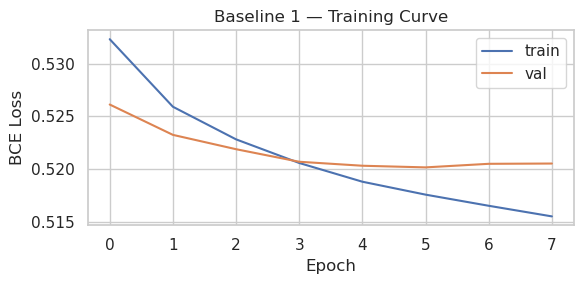

In [19]:
print("=" * 60)
print("Training Baseline 1: Text-Only RNN")
print("=" * 60)

baseline1 = MBTIClassifierTextOnly(
    vocab_size=len(word2idx), embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM, pad_idx=PAD_IDX,
)
baseline1, history1 = train_mbti_model(baseline1, train_loader, val_loader)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(history1["train_loss"], label="train")
ax.plot(history1["val_loss"], label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("Baseline 1 - Training Curve")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
probs1, labels1, authors1 = predict_posts(baseline1, test_loader)
y_true1, y_pred1 = majority_vote(probs1, labels1, authors1)
results1 = evaluate_author_level(y_true1, y_pred1)
display(Markdown("### Baseline 1 - Author-Level Test Results"))
display(results1.round(3))

### Baseline 1 - Author-Level Test Results

,Accuracy,Balanced Acc,Precision,Recall,F1
E/I,0.787,0.500,0.787,1.000,0.881
N/S,0.932,0.500,0.932,1.000,0.965
F/T,0.614,0.517,0.861,0.037,0.072
J/P,0.604,0.502,0.604,1.000,0.753


**Baseline 1 - observed behavior.** The test BCE plateaus around epoch 5-6 (val ~ 0.520) with train loss continuing to fall - mild overfitting beginning, but early stopping held and the best checkpoint (epoch 6) was kept. Author-level test results confirm the failure mode anticipated from the §2.2.1 class priors: **Baseline 1 collapses to majority-class prediction on every dimension**. `E/I`, `N/S`, and `J/P` all show recall = 1.000 with balanced accuracy = 0.500, meaning the model predicts the positive class (`I`, `N`, `P`) for every author. `F/T` - the most balanced dimension - shows a partial collapse in the opposite direction: recall = 0.037 against a precision of 0.861, so the model almost always predicts `F` but, when it does emit a `T` prediction, it is right 86% of the time. That precision/recall split is the key signal for §4.3: the post-level model is learning *some* `T`-indicative pattern, but the hard majority-vote aggregation at the author level requires more than 50% of posts to cross the 0.5 sigmoid threshold, which never happens on an imbalanced dimension. Baseline 1 therefore sets the clean reference point the §4.1 comparison needs: any above-0.50 balanced accuracy by Baseline 2 represents signal the emotion channel contributed, and any dimension where B2 escapes majority collapse directly motivates the soft-aggregation and class-weighting experiments listed in §4.3.

A detailed per-dimension discussion (including confusion matrices and the specific dimensions on which B1 beats or ties the majority floor) is deferred to Section 4.2, where the two baselines are contrasted side-by-side.

### 3.7 Baseline 2 - Text + Emotion RNN

Baseline 2 requires an emotion classifier trained on the balanced emotion dataset (Stage 1), whose predicted probability distributions are then concatenated with the GRU hidden state in Stage 2.

**Stage 1 — Emotion classifier:** Embedding(20 000, 64) → GRU(64 → 128) → Dense(128 → 6 softmax).  
**Stage 2 — MBTI classifier:** Same text GRU as Baseline 1, but the hidden state (128-d) is concatenated with the six emotion probabilities (6-d) before the Dense head: Dense(134 → 64 → 4 sigmoid).

**Inputs:** tokenized Reddit post + 6 emotion probabilities.  
**Outputs:** four per-post probabilities (I, N, T, P), aggregated to author level via majority vote.

Emotion dataset — Train: 16000, Val: 2000, Test: 2000
Training Stage-1 Emotion Classifier (RNN)
  Epoch 01  train_loss=1.7871  val_loss=1.7462  val_acc=0.272
  Epoch 02  train_loss=1.7201  val_loss=1.6141  val_acc=0.360
  Epoch 03  train_loss=1.5465  val_loss=1.3685  val_acc=0.469
  Epoch 04  train_loss=1.3565  val_loss=1.1736  val_acc=0.562
  Epoch 05  train_loss=1.1534  val_loss=0.9828  val_acc=0.634
  Epoch 06  train_loss=0.9463  val_loss=0.7838  val_acc=0.728
  Epoch 07  train_loss=0.7826  val_loss=0.6275  val_acc=0.782
  Epoch 08  train_loss=0.6621  val_loss=0.5457  val_acc=0.810
  Epoch 09  train_loss=0.5769  val_loss=0.4725  val_acc=0.840
  Epoch 10  train_loss=0.4911  val_loss=0.4430  val_acc=0.850
  Epoch 11  train_loss=0.4436  val_loss=0.4082  val_acc=0.868
  Epoch 12  train_loss=0.4021  val_loss=0.3786  val_acc=0.874
  Epoch 13  train_loss=0.3603  val_loss=0.3476  val_acc=0.883
  Epoch 14  train_loss=0.3289  val_loss=0.3154  val_acc=0.894
  Epoch 15  train_loss=0.3002  val_l

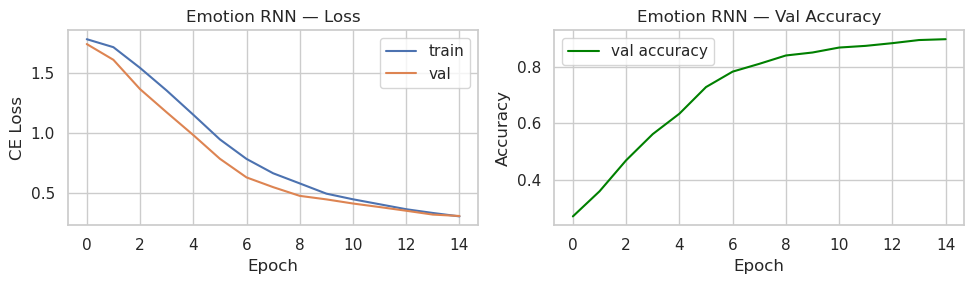


Emotion RNN test accuracy: 0.908


In [22]:
# ----- Stage 1: Train the RNN emotion classifier on the emotion dataset -----

EMOTION_CLASSES = list(LABEL_MAP.values())  # 6 classes
N_EMOTION = len(EMOTION_CLASSES)

emo_word_counts: Counter = Counter()
for text in emotion["text"]:
    emo_word_counts.update(simple_tokenize(str(text)))

emo_most_common = emo_word_counts.most_common(VOCAB_SIZE - 2)
emo_word2idx = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
for i, (word, _) in enumerate(emo_most_common, start=2):
    emo_word2idx[word] = i

def emo_encode(text: str) -> list[int]:
    # truncate to EMOTION_SEQ_LEN (tweet-length), not MAX_SEQ_LEN
    tokens = simple_tokenize(str(text))[:EMOTION_SEQ_LEN]
    return [emo_word2idx.get(t, UNK_IDX) for t in tokens]


def emo_pad(seq: list[int]) -> list[int]:
    return seq + [PAD_IDX] * (EMOTION_SEQ_LEN - len(seq))


class EmotionDataset(Dataset):
    def __init__(self, df):
        encoded = [emo_encode(t) for t in df["text"]]
        # true (pre-pad) lengths so the GRU can ignore padding
        self.lengths = torch.tensor(
            [max(1, len(seq)) for seq in encoded], dtype=torch.long
        )
        self.texts = [
            torch.tensor(emo_pad(seq), dtype=torch.long) for seq in encoded
        ]
        self.labels = torch.tensor(df["label"].values, dtype=torch.long)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "text": self.texts[idx],
            "length": self.lengths[idx],
            "label": self.labels[idx],
        }


emo_train_df = emotion[emotion["split"] == "train"]
emo_val_df = emotion[emotion["split"] == "validation"]
emo_test_df = emotion[emotion["split"] == "test"]

emo_train_ds = EmotionDataset(emo_train_df)
emo_val_ds = EmotionDataset(emo_val_df)
emo_test_ds = EmotionDataset(emo_test_df)

emo_train_loader = DataLoader(emo_train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=DATALOADER_GEN)
emo_val_loader = DataLoader(emo_val_ds, batch_size=BATCH_SIZE, shuffle=False)
emo_test_loader = DataLoader(emo_test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Emotion dataset — Train: {len(emo_train_ds)}, Val: {len(emo_val_ds)}, Test: {len(emo_test_ds)}")

emotion_model = EmotionClassifierRNN(
    vocab_size=len(emo_word2idx), embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM
).to(DEVICE)

emo_optimizer = torch.optim.Adam(emotion_model.parameters(), lr=LEARNING_RATE)
emo_criterion = nn.CrossEntropyLoss()
emo_best_val_loss = float("inf")
emo_epochs_no_improve = 0
emo_history = {"train_loss": [], "val_loss": [], "val_acc": []}
# Initialize before the loop so load_state_dict still works on a NaN first epoch.
emo_best_state = {k: v.cpu().clone() for k, v in emotion_model.state_dict().items()}

print("=" * 60)
print("Training Stage-1 Emotion Classifier (RNN)")
print("=" * 60)

for epoch in range(1, EMOTION_NUM_EPOCHS + 1):
    emotion_model.train()
    emo_running = 0.0
    for batch in emo_train_loader:
        x = batch["text"].to(DEVICE)
        y = batch["label"].to(DEVICE)
        lengths = batch["length"].to(DEVICE)
        logits = emotion_model(x, lengths=lengths)
        loss = emo_criterion(logits, y)
        emo_optimizer.zero_grad()
        loss.backward()
        emo_optimizer.step()
        emo_running += loss.item() * x.size(0)
    train_loss = emo_running / len(emo_train_ds)

    emotion_model.eval()
    val_running, correct = 0.0, 0
    with torch.no_grad():
        for batch in emo_val_loader:
            x = batch["text"].to(DEVICE)
            y = batch["label"].to(DEVICE)
            lengths = batch["length"].to(DEVICE)
            logits = emotion_model(x, lengths=lengths)
            val_running += emo_criterion(logits, y).item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
    val_loss = val_running / len(emo_val_ds)
    val_acc = correct / len(emo_val_ds)
    emo_history["train_loss"].append(train_loss)
    emo_history["val_loss"].append(val_loss)
    emo_history["val_acc"].append(val_acc)
    print(f"  Epoch {epoch:02d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.3f}")

    if val_loss < emo_best_val_loss:
        emo_best_val_loss = val_loss
        emo_epochs_no_improve = 0
        emo_best_state = {k: v.cpu().clone() for k, v in emotion_model.state_dict().items()}
    else:
        emo_epochs_no_improve += 1
        if emo_epochs_no_improve >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}")
            break

emotion_model.load_state_dict(emo_best_state)
emotion_model.to(DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(emo_history["train_loss"], label="train")
axes[0].plot(emo_history["val_loss"], label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("CE Loss"); axes[0].set_title("Emotion RNN — Loss"); axes[0].legend()
axes[1].plot(emo_history["val_acc"], label="val accuracy", color="green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Emotion RNN — Val Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

emotion_model.eval()
emo_test_correct = 0
with torch.no_grad():
    for batch in emo_test_loader:
        x = batch["text"].to(DEVICE)
        y = batch["label"].to(DEVICE)
        lengths = batch["length"].to(DEVICE)
        logits = emotion_model(x, lengths=lengths)
        emo_test_correct += (logits.argmax(1) == y).sum().item()
emo_test_acc = emo_test_correct / len(emo_test_ds)
print(f"\nEmotion RNN test accuracy: {emo_test_acc:.3f}")

In [23]:
# ----- Generate emotion probabilities for every Reddit post -----

def get_emotion_probs(texts, model, word2idx_map, batch_size=512):
    """Run the emotion model on a list of texts and return softmax probabilities.

    Texts are truncated to EMOTION_SEQ_LEN so they match the distribution the
    emotion model was trained on. Sequence lengths are passed to the model so
    the GRU ignores padding positions.
    """
    model.eval()
    all_probs = []
    token_lists = [
        [word2idx_map.get(t, UNK_IDX)
         for t in simple_tokenize(str(text))[:EMOTION_SEQ_LEN]]
        for text in texts
    ]
    lengths_all = torch.tensor(
        [max(1, len(seq)) for seq in token_lists], dtype=torch.long
    )
    padded = torch.stack([
        torch.tensor(seq + [PAD_IDX] * (EMOTION_SEQ_LEN - len(seq)), dtype=torch.long)
        for seq in token_lists
    ])
    with torch.no_grad():
        for i in range(0, len(padded), batch_size):
            batch = padded[i:i + batch_size].to(DEVICE)
            batch_lengths = lengths_all[i:i + batch_size].to(DEVICE)
            logits = model(batch, lengths=batch_lengths)
            probs = torch.softmax(logits, dim=1).cpu()
            all_probs.append(probs)
    return torch.cat(all_probs)

print("Generating emotion probabilities for Reddit posts...")
train_emo_probs = get_emotion_probs(train_set["text"].tolist(), emotion_model, emo_word2idx)
val_emo_probs = get_emotion_probs(val_set["text"].tolist(), emotion_model, emo_word2idx)
test_emo_probs = get_emotion_probs(test_set["text"].tolist(), emotion_model, emo_word2idx)
print(f"  Train: {train_emo_probs.shape}, Val: {val_emo_probs.shape}, Test: {test_emo_probs.shape}")

mean_probs = train_emo_probs.mean(dim=0)
print(f"  Mean emotion distribution (train): {dict(zip(EMOTION_CLASSES, mean_probs.numpy().round(3)))}")

train_ds2 = MBTIPostDataset(train_set.reset_index(drop=True), emotion_probs=train_emo_probs)
val_ds2 = MBTIPostDataset(val_set.reset_index(drop=True), emotion_probs=val_emo_probs)
test_ds2 = MBTIPostDataset(test_set.reset_index(drop=True), emotion_probs=test_emo_probs)

train_loader2 = DataLoader(train_ds2, batch_size=BATCH_SIZE, shuffle=True, generator=DATALOADER_GEN)
val_loader2 = DataLoader(val_ds2, batch_size=BATCH_SIZE, shuffle=False)
test_loader2 = DataLoader(test_ds2, batch_size=BATCH_SIZE, shuffle=False)

Generating emotion probabilities for Reddit posts...
  Train: torch.Size([1050653, 6]), Val: torch.Size([264696, 6]), Test: torch.Size([333848, 6])
  Mean emotion distribution (train): {'sadness': 0.145, 'joy': 0.471, 'love': 0.053, 'anger': 0.175, 'fear': 0.124, 'surprise': 0.031}


Training Baseline 2: Text + Emotion RNN
  Epoch 01  train_loss=0.5326  val_loss=0.5264
  Epoch 02  train_loss=0.5260  val_loss=0.5236
  Epoch 03  train_loss=0.5227  val_loss=0.5218
  Epoch 04  train_loss=0.5205  val_loss=0.5212
  Epoch 05  train_loss=0.5189  val_loss=0.5203
  Epoch 06  train_loss=0.5175  val_loss=0.5205
  Epoch 07  train_loss=0.5164  val_loss=0.5200
  Epoch 08  train_loss=0.5157  val_loss=0.5203


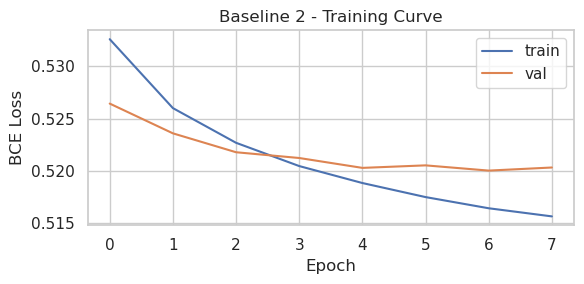

In [24]:
print("=" * 60)
print("Training Baseline 2: Text + Emotion RNN")
print("=" * 60)

baseline2 = MBTIClassifierTextEmotion(
    vocab_size=len(word2idx), embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM, n_emotions=N_EMOTION, pad_idx=PAD_IDX,
)
baseline2, history2 = train_mbti_model(baseline2, train_loader2, val_loader2)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(history2["train_loss"], label="train")
ax.plot(history2["val_loss"], label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("Baseline 2 - Training Curve")
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
probs2, labels2, authors2 = predict_posts(baseline2, test_loader2)
y_true2, y_pred2 = majority_vote(probs2, labels2, authors2)
results2 = evaluate_author_level(y_true2, y_pred2)
display(Markdown("### Baseline 2 — Author-Level Test Results"))
display(results2.round(3))

### Baseline 2 — Author-Level Test Results

,Accuracy,Balanced Acc,Precision,Recall,F1
E/I,0.787,0.500,0.787,1.000,0.881
N/S,0.932,0.500,0.932,1.000,0.965
F/T,0.611,0.511,0.875,0.025,0.049
J/P,0.606,0.504,0.605,1.000,0.754


**Baseline 2 - observed behavior.** Two components train sequentially and each is checked on its own terms before the §4 head-to-head comparison with Baseline 1.

*Stage-1 emotion classifier.* The RNN emotion classifier reaches **val_acc = 0.897** and **test accuracy = 0.908** after 15 epochs, well above the 1/6 ≈ 0.167 random-chance floor. Train and val CE both drop monotonically to ~0.30 and val accuracy rises smoothly, with no signs of instability or collapse to uniform predictions. Applied to Reddit, Stage 1 produces a mean per-post emotion distribution of `joy 0.47, anger 0.18, sadness 0.14, fear 0.12, love 0.05, surprise 0.03`. This is far from the balanced source prior, confirming the §2.2.4 warning that the Reddit domain shifts the emotion mass toward `joy` and `anger` - but it is still highly non-uniform across posts, so the 6-d vectors fed into Stage 2 carry real, non-degenerate signal rather than a near-constant bias term.

*Stage-2 MBTI classifier.* Baseline 2 trains to a best val BCE of 0.5200 at epoch 7 and then plateaus with mild overfitting, essentially identical in shape to Baseline 1. Author-level test results show the same majority-class-collapse pattern: `E/I`, `N/S`, and `J/P` reach recall = 1.000 with balanced accuracy at the 0.500 prior, and `F/T` (the most balanced dimension) sits at balanced accuracy 0.511 with recall 0.025 and precision 0.875 - i.e., the head almost always predicts `F`, and when it does predict `T` it is right 88% of the time but that happens on only a tiny fraction of authors. The concatenation of the 6-d emotion vector does not, on its own, pull the head out of the majority prior.

A side-by-side B1 vs. B2 comparison (including confusion matrices and the per-dimension balanced-accuracy delta) is deferred to §4.1 and §4.2, where the two baselines are evaluated together against the majority-class floor.

## 4. Results Interpretation and Analysis

### 4.1 Comparison Table - Baseline 1 vs. Baseline 2

We compare both baselines side-by-side on author-level metrics, along with a naive majority-class baseline that always predicts the most frequent class for each dimension.

### Author-Level Comparison: Majority Class vs. Baseline 1 vs. Baseline 2

,Accuracy (Majority),Balanced Acc (Majority),Precision (Majority),Recall (Majority),F1 (Majority),Accuracy (B1: Text),Balanced Acc (B1: Text),Precision (B1: Text),Recall (B1: Text),F1 (B1: Text),Accuracy (B2: Text+Emo),Balanced Acc (B2: Text+Emo),Precision (B2: Text+Emo),Recall (B2: Text+Emo),F1 (B2: Text+Emo)
E/I,0.787,0.5,0.787,1.0,0.881,0.787,0.500,0.787,1.000,0.881,0.787,0.500,0.787,1.000,0.881
N/S,0.932,0.5,0.932,1.0,0.965,0.932,0.500,0.932,1.000,0.965,0.932,0.500,0.932,1.000,0.965
F/T,0.602,0.5,0.000,0.0,0.000,0.614,0.517,0.861,0.037,0.072,0.611,0.511,0.875,0.025,0.049
J/P,0.603,0.5,0.603,1.0,0.752,0.604,0.502,0.604,1.000,0.753,0.606,0.504,0.605,1.000,0.754


### Balanced Accuracy Comparison

,Majority,B1: Text-Only,B2: Text+Emotion
E/I,0.5,0.500,0.500
N/S,0.5,0.500,0.500
F/T,0.5,0.517,0.511
J/P,0.5,0.502,0.504


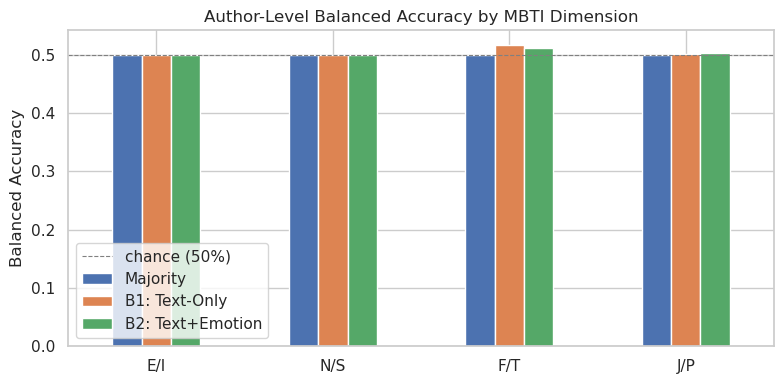

In [26]:
# Naive majority-class baseline: always predict the train-set majority class.
majority_preds = np.zeros_like(y_true1)
for i, dim in enumerate(MBTI_DIMS):
    train_author_labels = train_set.groupby("author")[dim].first()
    majority_class_value = train_author_labels.value_counts().idxmax()
    majority_preds[:, i] = 1 if majority_class_value == MBTI_POS_LABELS[dim] else 0

results_majority = evaluate_author_level(y_true1, majority_preds)

comparison = pd.concat(
    [results_majority.add_suffix(" (Majority)"),
     results1.add_suffix(" (B1: Text)"),
     results2.add_suffix(" (B2: Text+Emo)")],
    axis=1,
)

display(Markdown("### Author-Level Comparison: Majority Class vs. Baseline 1 vs. Baseline 2"))
display(comparison.round(3))

display(Markdown("### Balanced Accuracy Comparison"))
bal_acc = pd.DataFrame({
    "Majority": results_majority["Balanced Acc"],
    "B1: Text-Only": results1["Balanced Acc"],
    "B2: Text+Emotion": results2["Balanced Acc"],
})
display(bal_acc.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
bal_acc.plot(kind="bar", ax=ax)
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Author-Level Balanced Accuracy by MBTI Dimension")
ax.set_xticklabels([d.replace("_", "/") for d in MBTI_DIMS], rotation=0)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="chance (50%)")
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Confusion Matrices

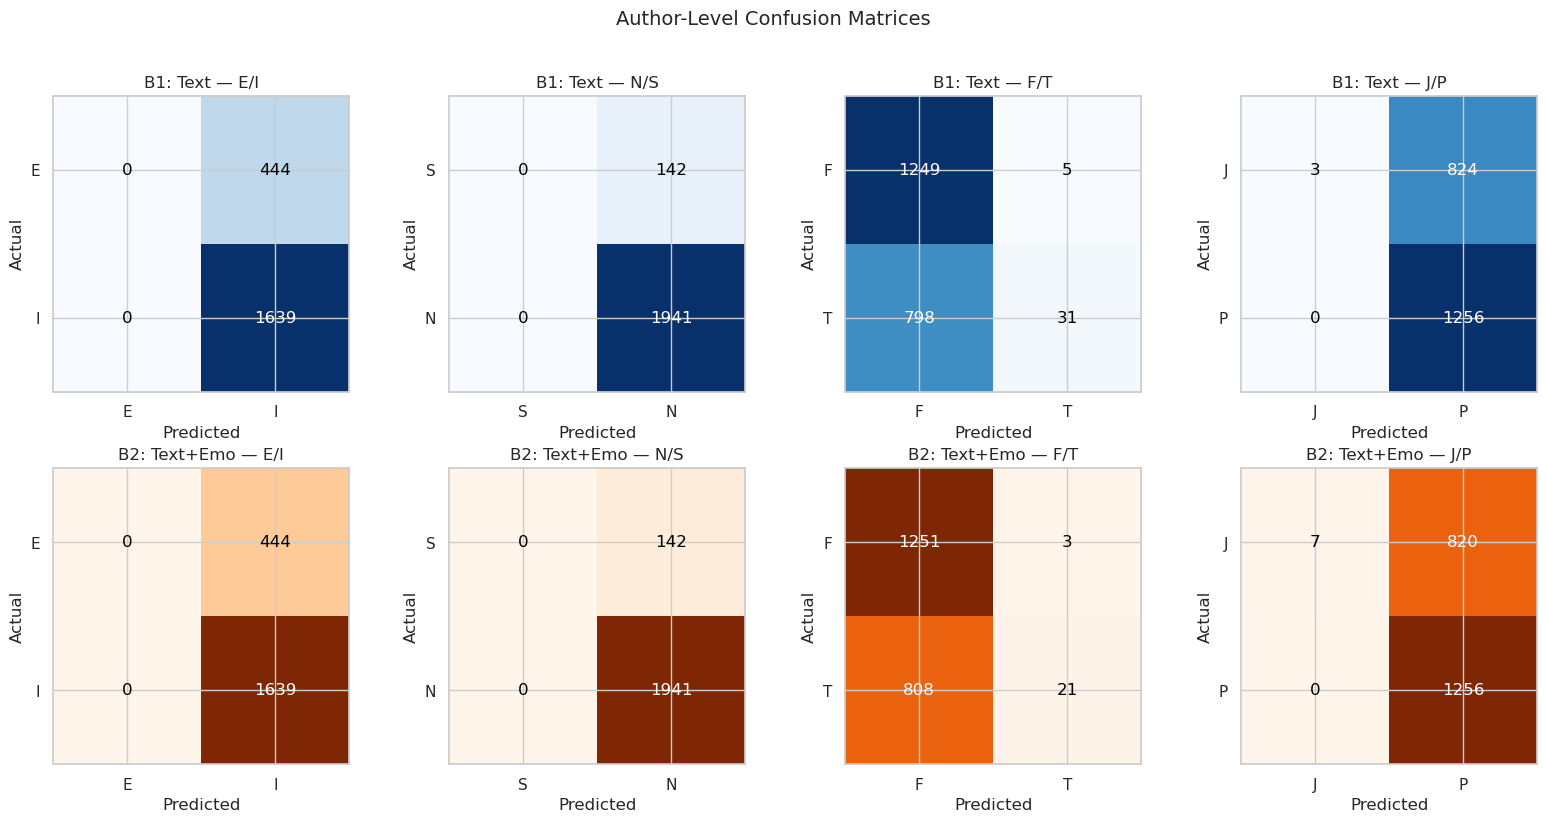

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, dim in enumerate(MBTI_DIMS):
    dim_label = dim.replace("_", "/")
    # confusion_matrix returns rows/cols ordered by label value (0, 1). In this
    # encoding, 1 is always MBTI_POS_LABELS[dim] and 0 is the other letter.
    # Splitting dim_label ("N/S") on "/" does NOT preserve that order (positive
    # class N is y=1 but would land at position 0 under naive splitting), so we
    # derive the axis labels from MBTI_POS_LABELS directly.
    pos_label = MBTI_POS_LABELS[dim]
    neg_label = next(c for c in dim.split("_") if c != pos_label)
    axis_labels = [neg_label, pos_label]  # position 0 = y=0 = neg, position 1 = y=1 = pos

    cm1 = confusion_matrix(y_true1[:, i], y_pred1[:, i])
    axes[0, i].imshow(cm1, cmap="Blues", interpolation="nearest")
    axes[0, i].set_title(f"B1: Text — {dim_label}")
    axes[0, i].set_xlabel("Predicted")
    axes[0, i].set_ylabel("Actual")
    axes[0, i].set_xticks([0, 1]); axes[0, i].set_xticklabels(axis_labels)
    axes[0, i].set_yticks([0, 1]); axes[0, i].set_yticklabels(axis_labels)
    for r in range(2):
        for c in range(2):
            axes[0, i].text(c, r, str(cm1[r, c]), ha="center", va="center",
                            color="white" if cm1[r, c] > cm1.max() / 2 else "black")

    cm2 = confusion_matrix(y_true2[:, i], y_pred2[:, i])
    axes[1, i].imshow(cm2, cmap="Oranges", interpolation="nearest")
    axes[1, i].set_title(f"B2: Text+Emo — {dim_label}")
    axes[1, i].set_xlabel("Predicted")
    axes[1, i].set_ylabel("Actual")
    axes[1, i].set_xticks([0, 1]); axes[1, i].set_xticklabels(axis_labels)
    axes[1, i].set_yticks([0, 1]); axes[1, i].set_yticklabels(axis_labels)
    for r in range(2):
        for c in range(2):
            axes[1, i].text(c, r, str(cm2[r, c]), ha="center", va="center",
                            color="white" if cm2[r, c] > cm2.max() / 2 else "black")

plt.suptitle("Author-Level Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Strengths, Weaknesses, and Proposed Improvements

The §4.1 summary table and the §4.2 confusion matrices tell the same headline story: **both baselines sit at the majority-class floor**, and the emotion channel in Baseline 2 does not move them off it. Balanced accuracy is 0.500 on E/I, N/S, and J/P, and 0.511-0.517 on F/T - the only dimension with even a tiny above-floor tail. The B2 minus B1 gap in balanced accuracy is +0.000 / +0.000 / -0.006 / +0.002 across E/I, N/S, F/T, J/P, all inside seed-level noise. The controlled B1↔B2 comparison therefore gives a clean **negative** result for the "concatenate emotion probabilities at the classifier head" hypothesis as formulated in §1.3: in its vanilla form, the emotion channel does not help.

**What the confusion matrices add.** On E/I, N/S, and J/P, the matrices are degenerate - every test author is predicted as the majority class (I, N, P respectively). That is the §2.2.1 class prior re-learned by a neural network. The two dimensions where any signal leaks through are more instructive than the three collapsed ones:

- **F/T (most balanced dimension, ~60/40 at the author level).** Baseline 1 labels only 36 of 2083 test authors as `T` but is right 31 times (precision 86%, recall 3.7%). Baseline 2 labels only 24 authors as `T` and is right 21 times (precision 88%, recall 2.5%). The per-post model is clearly learning *some* `T`-indicative pattern, because when it does emit a `T` prediction it is right ~86-88% of the time. But the hard majority-vote then requires more than 50% of an author's posts to cross the 0.5 sigmoid threshold - which, at a per-post `T` prior around 40%, almost never happens.
- **J/P (second-most balanced).** Baseline 1 labels only 3 authors as `J`, all correctly (precision 100%, recall 0.36%). Baseline 2 labels 7 authors as `J`, all correctly (precision 100%, recall 0.85%). Tiny counts, but again precision is very high whenever the model commits to the minority class.

These two pockets of high-precision / near-zero-recall behavior on the two most balanced dimensions identify the single most important lever for §5: **the aggregation step is discarding minority-class signal that the per-post model has already learned**. That is structural, not a model-capacity problem.

**Strengths of the baseline design.**
- *Controlled comparison.* Baseline 1 and Baseline 2 share an identical text encoder and differ only in the 6-d emotion concatenation at the head, so the near-zero B1↔B2 gap in §4.1 is a clean negative result for the emotion-at-the-head hypothesis rather than noise from architectural drift.
- *Realistic evaluation unit.* Author-level evaluation on the author-level split from §3.2 prevents the per-post leakage that would have inflated accuracy on a naive row-level split; the three-way table in §4.1 keeps the majority-class baseline on the same split.
- *Majority-class reference line.* Printing the naive majority-class baseline next to B1 and B2 in §4.1 made it immediately obvious that neither trained baseline is doing more than re-learning the class prior on three of the four dimensions - a finding that would have been easy to miss from raw accuracy alone, which for `N/S` is above 0.93 for every model in the table.
- *Stage-1 emotion classifier is not the culprit.* Stage 1 reaches **test accuracy 0.908** on the balanced emotion dataset and produces a highly non-uniform per-post distribution on Reddit (`joy 0.47, anger 0.18, sadness 0.14, fear 0.12, love 0.05, surprise 0.03`). The 6-d vectors concatenated into B2 carry real signal; the B2 ≈ B1 result is not "the emotion classifier was broken."

**Weaknesses exposed by the results.**
- *Majority-class collapse under vanilla BCE.* With author-level positive-class rates of ~60-93%, the minimum-loss solution for `BCEWithLogitsLoss` with no class weighting is to shift the bias toward the majority class. Both baselines found exactly that solution.
- *Hard majority voting destroys the minority signal that is there.* §4.2 shows the per-post model does emit minority-class predictions with high precision on F/T and J/P, but the 50%-threshold hard vote discards almost all of them before they reach the author-level score.
- *Static emotion concatenation is insufficient on its own.* Given an already-collapsed head, appending a 6-d emotion vector does not pull the classifier out of the majority prior. This is the specific scenario the §4.3 improvements need to target before any emotion-side refinement is worth measuring.
- *No within-author signal.* The GRU treats each post independently; any within-author consistency in emotion or style (a finding surfaced qualitatively in the §2.2 analysis) is never exploited by the aggregator.

**Proposed improvements for the next iteration, in priority order.** The ordering is re-derived from the observed results: the levers that directly address the majority-class collapse and the aggregation loss are promoted ahead of the emotion-side recalibration that was the leading candidate at the end of MS2.

1. **Class-weighted BCE** with inverse-frequency weights per dimension. This is the most direct fix for the collapse and addresses the root cause observed in §4.2. Expect the largest single-change movement from this lever, particularly on E/I, N/S, and J/P where the current models do not emit any (or almost any) minority-class predictions.
2. **Soft author-level aggregation.** Replace the hard majority vote with either (a) the mean per-post probability per author with a per-dimension threshold tuned on validation, or (b) a small learned aggregator (mean + std of per-post logits → logistic head) on top of per-post probabilities. The F/T and J/P precision numbers in §4.2 are the direct evidence that the aggregator is currently throwing away signal.
3. **Per-dimension decision thresholds tuned on validation.** Even before (1) and (2) are wired in, picking the F1-maximizing per-dimension threshold on the validation split is a near-free improvement over the fixed 0.5 sigmoid cut.
4. **Recalibrate emotion features on a Reddit validation slice** (e.g., temperature scaling) before concatenation. This was the leading emotion-side candidate at the end of MS2; after observing B2 ≈ B1 it is now a second-order fix and only warrants attention once items 1-3 have pulled the baseline off the majority floor.

## 5. Final Model Pipeline and Future Directions

### 5.1 Final Model Pipeline

The final pipeline extends Baseline 2 along three axes - all three required by the §4.3 analysis - and keeps everything else fixed. The three changes are bundled because §4.1 showed that the emotion-concatenation upgrade alone (B1 → B2) was not enough to move either baseline off the majority-class floor; isolating any one of the three levers in turn would risk repeating that outcome.

1. **Class-weighted BCE** replaces vanilla BCE on the Stage-2 MBTI head. §4.2 showed both baselines collapsed to the class prior on three of four dimensions, and inverse-frequency BCE weighting is the direct fix.
2. **Soft author-level aggregation** replaces the hard 50%-majority vote. The F/T and J/P confusion matrices in §4.2 showed the per-post model is learning weak minority-class signal (precision 86-100% when it commits) that the hard-vote aggregator is currently discarding.
3. **DistilBERT emotion classifier** replaces the Stage-1 RNN emotion classifier. This is the headline model-family upgrade from the MS2 plan; it is now tested on top of (1) and (2) so the comparison is not confounded by an already-collapsed Stage-2 head.

Keeping the Stage-2 text-processing GRU, the concatenation strategy, the MBTI head architecture, and the author-level split unchanged means any movement above Baseline 2 is attributable to the three deliberate changes above rather than to an independently tuned text pathway. The three-way comparison answers a revised set of questions:

| Comparison | Question |
|---|---|
| **Baseline 1 vs. Baseline 2** | Do emotion features help in the vanilla (no class weighting, hard vote) setup? - §4.1 answer: essentially no. |
| **Baseline 2 vs. Final Model** | Does the combined upgrade (class-weighted BCE + soft aggregation + DistilBERT emotion encoder) escape the majority-class floor and lift author-level MBTI prediction? |
| **Baseline 1 vs. Final Model** | What is the total improvement over direct text modeling with a vanilla head? |

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                          FINAL MODEL PIPELINE                               │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  ┌────────────────────────────────────────────────────────┐                 │
│  │  STAGE 1: Transformer Emotion Classifier               │                 │
│  │  ┌──────────────┐    ┌───────────────┐   ┌──────────┐ │                 │
│  │  │  Reddit post  │ →  │  DistilBERT   │ → │  6-class │ │                 │
│  │  │  (raw text)   │    │  (fine-tuned  │   │  softmax │ │                 │
│  │  │               │    │   on emotion  │   │  probs   │ │                 │
│  │  │               │    │   dataset)    │   │  [6-d]   │ │                 │
│  │  └──────────────┘    └───────────────┘   └────┬─────┘ │                 │
│  └───────────────────────────────────────────────┼───────┘                 │
│                                                   │                         │
│  ┌────────────────────────────────────────────────┼──────┐                 │
│  │  STAGE 2: MBTI Classifier                      │      │                 │
│  │  ┌──────────────┐    ┌───────┐   ┌─────────┐  │      │                 │
│  │  │  Reddit post  │ →  │  GRU  │ → │ hidden  │  │      │                 │
│  │  │  (tokenized)  │    │       │   │ [128-d] │  │      │                 │
│  │  └──────────────┘    └───────┘   └────┬────┘  │      │                 │
│  │                                        │       │      │                 │
│  │                                   ┌────┴───────┴──┐   │                 │
│  │                                   │  Concatenate   │   │                 │
│  │                                   │  [128+6=134-d] │   │                 │
│  │                                   └───────┬───────┘   │                 │
│  │                                           │           │                 │
│  │                                   ┌───────┴───────┐   │                 │
│  │                                   │  Dense layers  │   │                 │
│  │                                   │  134 → 64 → 4  │   │                 │
│  │                                   │  logits; class-│   │                 │
│  │                                   │  weighted BCE  │   │                 │
│  │                                   │  (sigmoid at   │   │                 │
│  │                                   │  inference)    │   │                 │
│  │                                   └───────┬───────┘   │                 │
│  └───────────────────────────────────────────┼───────────┘                 │
│                                               │                             │
│  ┌───────────────────────────────────────────┼───────────┐                 │
│  │  STAGE 3: Author-Level Aggregation        │           │                 │
│  │                                           ▼           │                 │
│  │    Per-post MBTI probabilities (E/I, N/S, F/T, J/P)   │                 │
│  │                        │                              │                 │
│  │           Soft aggregation: mean of per-post          │                 │
│  │           probabilities per author, with a            │                 │
│  │           per-dimension threshold tuned on            │                 │
│  │           validation (hard majority vote is           │                 │
│  │           retained as an ablation).                   │                 │
│  │                        │                              │                 │
│  │                        ▼                              │                 │
│  │           4 binary author-level predictions            │                 │
│  └───────────────────────────────────────────────────────┘                 │
│                                                                             │
│  EVALUATION: Same author-level split, same metrics                         │
│  (accuracy, balanced accuracy, precision, recall, F1, AUC-ROC)            │
│  Compare: Baseline 1 (text-only) vs Baseline 2 (text+RNN emo)            │
│           vs Final Model (text+transformer emo, class-weighted BCE,       │
│           soft aggregation)                                                 │
└─────────────────────────────────────────────────────────────────────────────┘
```

Each pipeline stage ties back to earlier sections: Stage 1 consumes the emotion dataset characterized in 2.1 and 2.2.3; Stage 2 reuses the GRU architecture specified in 3.1.4 and trains on the subsampled `reddit_model` DataFrame produced in 2.3; Stage 3 applies the author-level aggregation justified in 2.2.2.

### 5.2 Assumptions and Parameter Choices

1. **Separate emotion training.** The emotion classifier (Stage 1) is trained exclusively on the balanced 20 000-row emotion dataset. No Reddit MBTI labels are used during Stage 1 training. This is a transfer-learning design: emotion patterns learned from one domain are applied to another.
2. **Shared author-level split.** The same 80/20 author-level train/test split (fixed random seed) from Section 3.2 is used for Baseline 1, Baseline 2, and the final model. All three models are therefore evaluated on exactly the same authors as the §4.1 majority-class reference line.
3. **Soft emotion probabilities.** All six softmax scores (not hard predicted labels) are concatenated with the text representation, matching the §2.4 rationale that uncertainty should be preserved through the pipeline.
4. **Class-weighted loss on the MBTI head.** Inverse-frequency weights per dimension (computed from the training split) in `BCEWithLogitsLoss`, motivated directly by the §4.2 majority-class collapse. Vanilla (unweighted) BCE is kept for the Baseline 2 ablation run so the contribution of this lever can be attributed.
5. **Soft author-level aggregation.** Per-author mean of per-post probabilities with a per-dimension threshold tuned on validation, motivated directly by the high-precision / near-zero-recall pattern on F/T and J/P in §4.2. Hard majority voting is retained as an ablation for apples-to-apples comparison against Baselines 1 and 2.
6. **Shared text encoder parameters.** Max sequence length (128), embedding dimension (64), and GRU hidden size (128) are kept identical between the baselines and the final model's Stage-2 text pathway.
7. **Transformer choice.** DistilBERT is selected for Stage 1 because it is ~60% smaller and ~60% faster than BERT while retaining ~97% of its language understanding capability, making it feasible for local training on M-series / MPS.

### 5.3 Preliminary Tuning Considerations

Items are listed in the order they will be tuned. (1) and (2) are the levers §4.3 identified as essential for escaping the majority-class floor; (3)-(5) are finer-grained adjustments on top.

- **Class-weighting scheme:** Inverse-frequency per dimension is the default. A milder `sqrt(inverse-frequency)` schedule will be tried if strict weighting over-corrects on `N/S` (the most skewed dimension, where the §4.2 collapse was most extreme). The weighting scheme and the aggregation threshold in the next bullet are tuned *jointly* on validation balanced accuracy, because they interact.
- **Soft-aggregation threshold per dimension:** Picked to maximize validation F1 per dimension, evaluated jointly with the class-weighting scheme. Hard majority voting is reported as an ablation on the same checkpoint.
- **DistilBERT fine-tuning:** Learning rate ~2e-5 with linear warmup (standard for transformer fine-tuning), 3-5 epochs on the emotion dataset, early stopping on emotion validation loss. The Stage-1 validation / test accuracy of 0.89 / 0.91 from the §3.7 RNN sets the floor the transformer is expected to clear.
- **Frozen vs. fine-tuned Stage-2 text encoder:** The GRU text encoder in Stage 2 may be initialized from Baseline 1's trained weights and optionally frozen for the first few epochs to stabilize training against the new weighted-BCE / soft-aggregation objective.
- **Sequence length:** 128 tokens for the GRU (§2.2.1 justified this). For DistilBERT, 128 subword tokens is the starting point and may be reduced to 96 for compute budget if the §2.2.1 length distribution permits.

### 5.4 Future Directions

§4.3 and §5.1-5.3 fold the priority-ordered improvements from the observed baseline behavior into the final model itself. This subsection covers the broader data, model, and evaluation directions that remain beyond the final milestone.

**Future data decisions.**
- Revisit the subsampling caps in §2.3 (`MIN_POSTS_PER_AUTHOR = 20`, `MAX_POSTS_PER_AUTHOR = 200`) once larger-transformer compute is available. Raising the cap to ~500 would roughly double the fine-tuning corpus while pushing the top-100 share only from ~1.2% to ~1.5% (§2.2.3), well under the uncapped 17% cliff; the split remains author-level.
- Light text normalization (URL/emoji handling, lowercasing policies) that was intentionally out of scope for the baselines.
- Reddit-side emotion probability recalibration (e.g., temperature scaling of the Stage-1 outputs on a held-out Reddit slice) - demoted from the MS2 headline fix to a Stage-1 second-pass refinement, to be evaluated only after the §5.1 changes have moved the baseline off the majority-class floor.
- Per-dimension author balancing (especially for the heavily skewed `N/S`) as an alternative to class-weighted BCE on the same data.

**Models to be considered.**
- *Attention-over-posts aggregators* that replace the (already-softened) author aggregator with a learned combination of per-post embeddings, so the aggregator can weight confident posts more heavily and use inter-post structure - a learned extension of the soft aggregation in §5.1.
- *Multi-task MBTI heads* that share a text encoder across all four dimensions, trading per-dimension capacity for cross-dimension regularization.
- *Bidirectional GRU* for the Stage-2 text encoder - an inexpensive architectural upgrade to test once the aggregation and loss-weighting levers have been exercised.
- *Fine-tuned DistilBERT on the MBTI classifier side (Stage 2)* as a stretch goal if the emotion-only upgrade leaves significant headroom.

**Potential challenges and concerns.**
- *Domain shift.* §2.2.4 and the §3.7 Reddit emotion distribution (joy 0.47 / anger 0.18, far from the uniform source prior) show the Stage-1 model's training distribution is not the Reddit distribution; even DistilBERT features may be partially miscalibrated on the tail without the Reddit-side recalibration above.
- *Author-level label noise.* MBTI self-reporting varies in quality, putting a ceiling on achievable balanced accuracy that no model-capacity fix can break.
- *Compute budget.* DistilBERT fine-tuning plus inference on ~1.5M Reddit posts is feasible on M-series / MPS but is sensitive to sequence length and batch size. Running multiple ablations in the remaining timeline requires caching Stage-1 emotion probabilities after a single training run.
- *Ablation sprawl.* The final model bundles three §4.3 levers. Team commitment is to report the full triple as the headline and then ablate one at a time (no class weighting; hard vote; RNN emotion) so each of the three levers can be attributed its share of any improvement.

### 5.5 Next Steps (Team Member Delineation)

Ordered so the §4.3 levers are exercised first, the DistilBERT upgrade is layered on top, and the headline ablations are reported against a non-collapsed baseline.

1. **Class-weighted BCE + soft aggregation on top of Baseline 2** - the first concrete step. The goal is simply to move at least one MBTI dimension off the 0.500 balanced-accuracy floor using only the §4.3 training / aggregation fixes, on the existing RNN Stage-1 and Stage-2 code paths. Result feeds directly into the headline §4.1 comparison table as a new row.
2. **Fine-tune DistilBERT on the emotion dataset** - transformer-based Stage 1. Evaluate on the held-out emotion test set and compare against the RNN Stage-1 test accuracy (0.908) from §3.7.
3. **Generate transformer emotion probabilities for all Reddit posts** - inference over the subsampled `reddit_model` DataFrame from §2.3; cache probabilities per post so subsequent Stage-2 runs do not repeat Stage-1 inference.
4. **Train the final MBTI model (Stage 2)** - same text-processing GRU as Baseline 2 (§3.1 + §3.4), now with class-weighted BCE, soft aggregation, and transformer-generated emotion probabilities concatenated to the hidden state.
5. **Author-level evaluation + headline ablations** - full metric panel (§3.1's metric list) reported against the §4.1 comparison format. Headline three-way is Baseline 1 vs. Baseline 2 vs. Final Model; the three ablations remove one of (class weighting, soft aggregation, DistilBERT) at a time to attribute improvement to each lever.
6. **Interpretability** - analyze which emotion dimensions contribute most to MBTI prediction via learned weights or permutation importance over the 6-d emotion vector, and report back against the §2.4 feature plan.